scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility ---

--- Step 1: Loading and Annotating paul15 Data ---
Data loading and labeling complete.

--- Step 2: Splitting Data ---
Data splitting complete.


--- Step 4: Running Comparative Analyses on paul15 ---

  RUNNING EXPERIMENT: Linear SVM (2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=1.0, class_weight='None'...
Training finished.
--- ScP

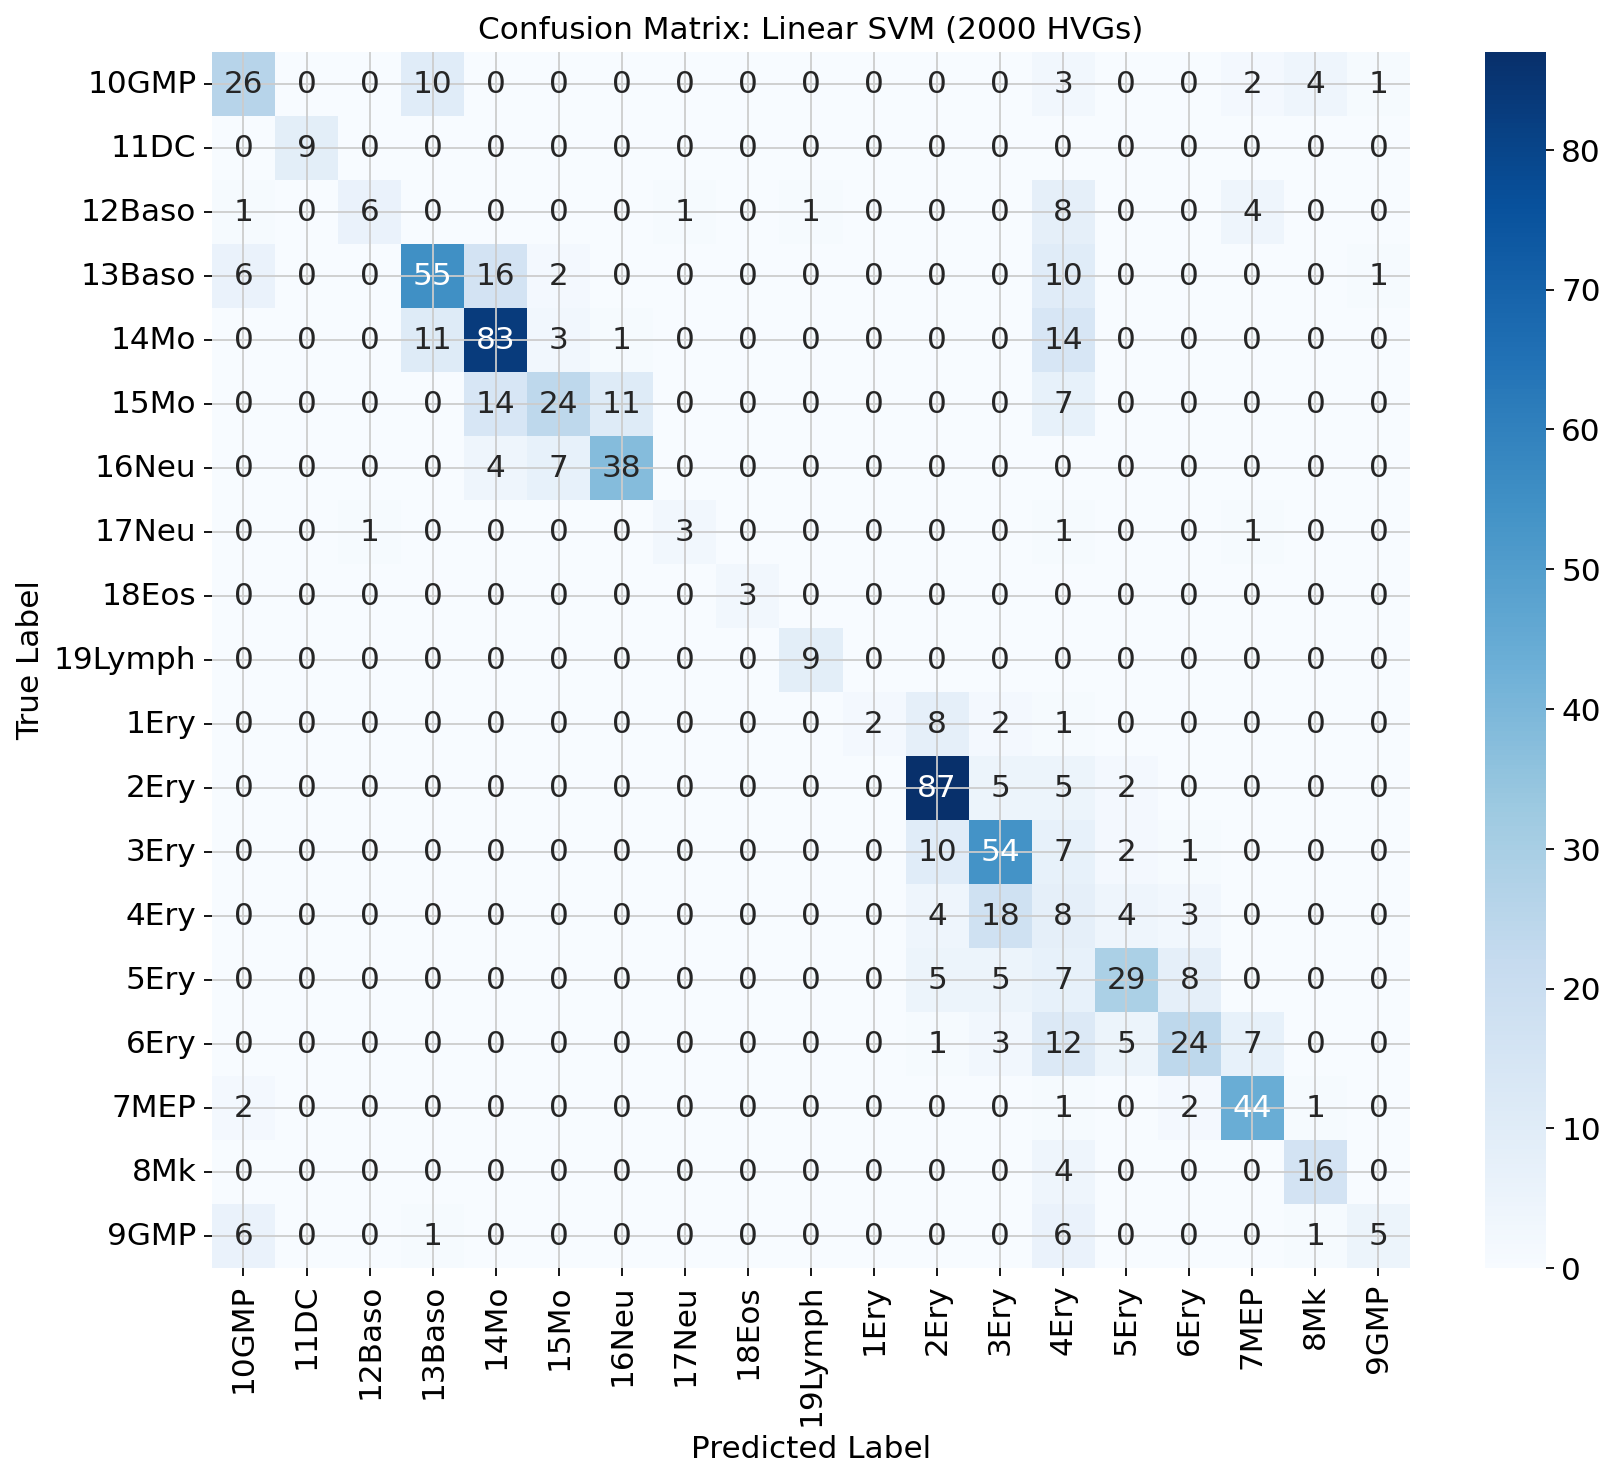


  RUNNING EXPERIMENT: RBF SVM (2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to 2000 reference genes

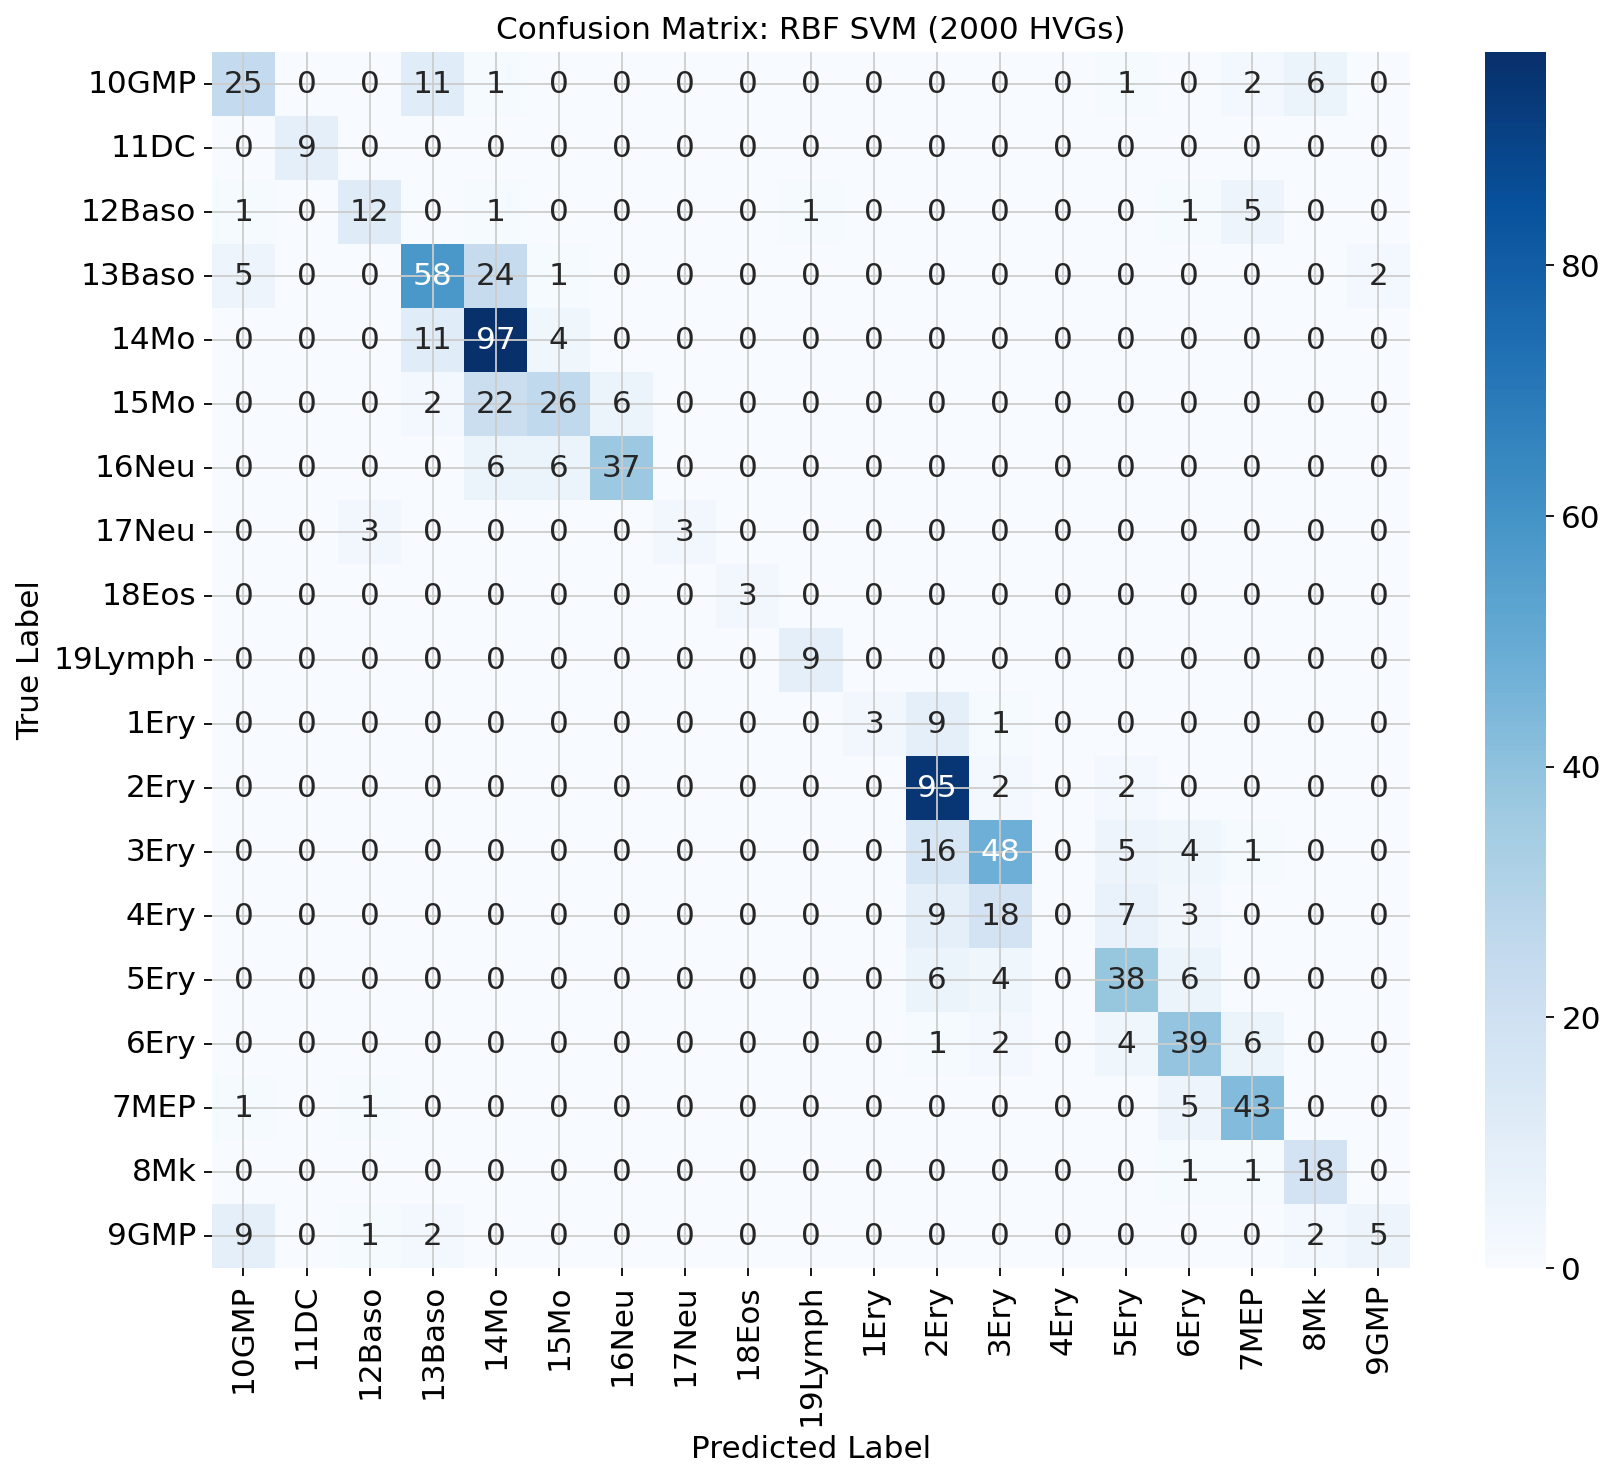


  RUNNING EXPERIMENT: RBF SVM (Balanced, 2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to 2000 r

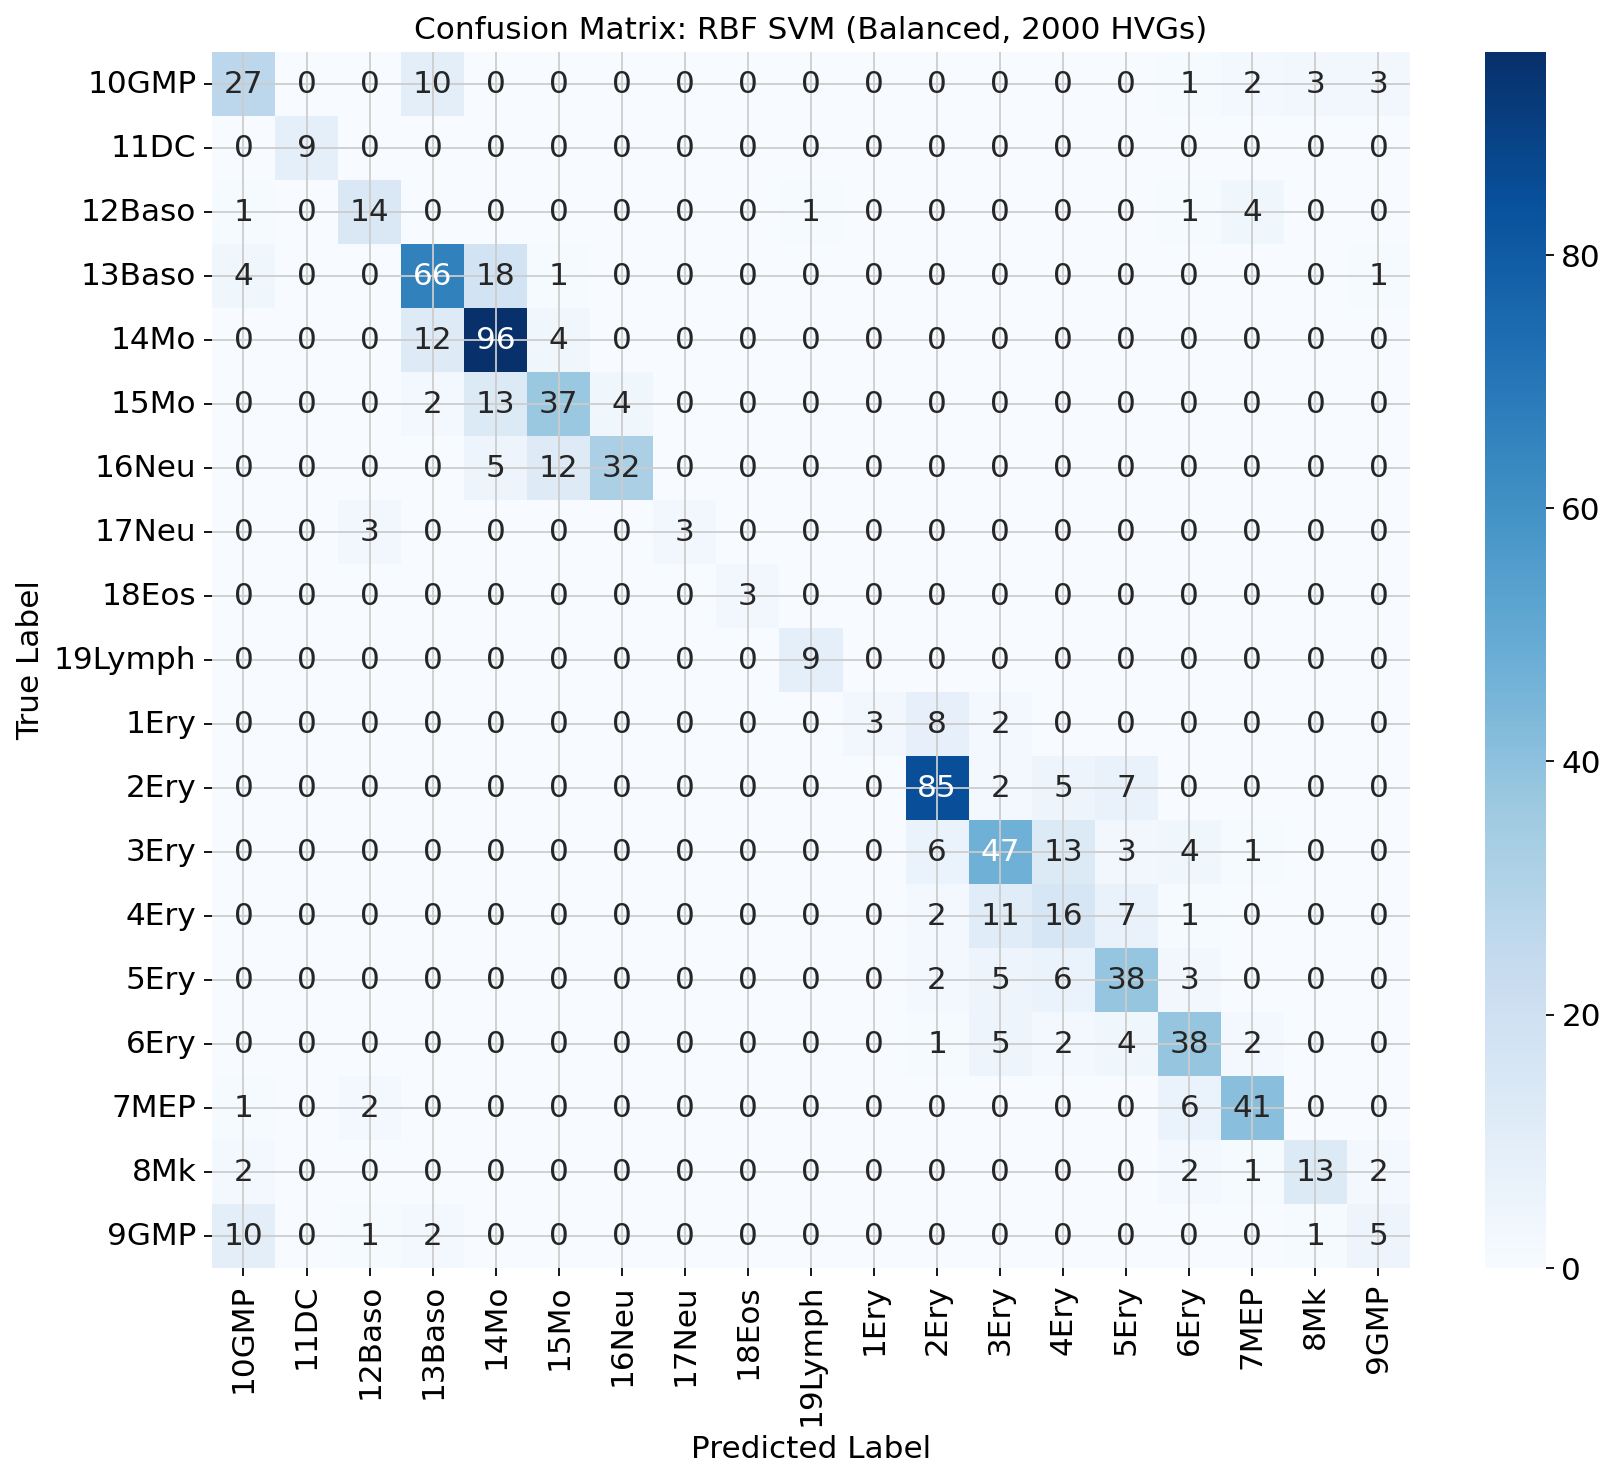


  RUNNING EXPERIMENT: RBF SVM (Balanced, C=10, 2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to

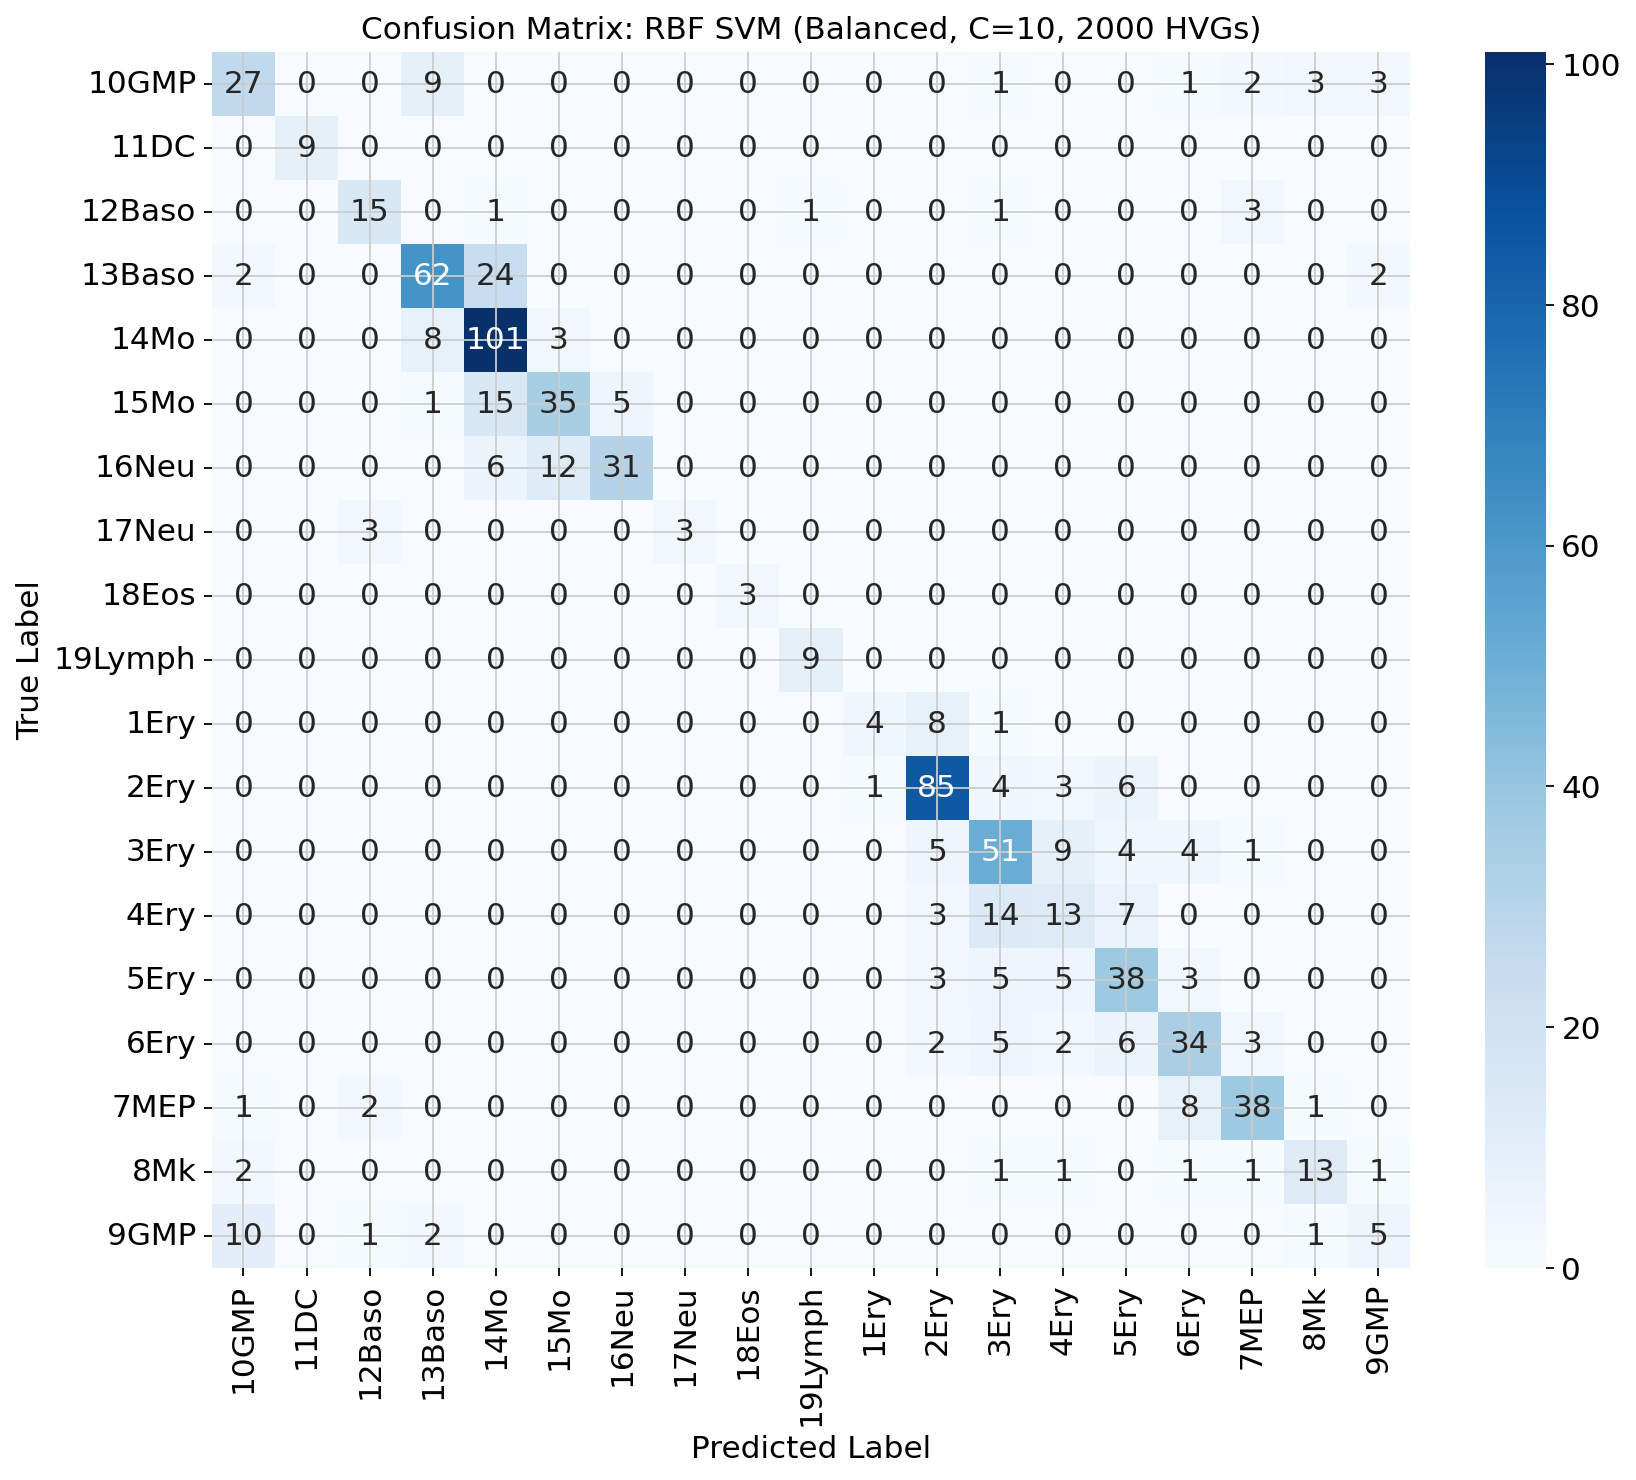



  FINAL RESULTS SUMMARY (paul15)
| Experiment                          |   Accuracy |   Balanced Accuracy |      MCC |
|:------------------------------------|-----------:|--------------------:|---------:|
| Linear SVM (2000 HVGs)              |   0.641026 |            0.6225   | 0.611044 |
| RBF SVM (2000 HVGs)                 |   0.693529 |            0.666352 | 0.666368 |
| RBF SVM (Balanced, 2000 HVGs)       |   0.710623 |            0.683286 | 0.684257 |
| RBF SVM (Balanced, C=10, 2000 HVGs) |   0.703297 |            0.678268 | 0.676347 |

--- Analysis Complete ---


In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# Adjust the path to import your package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scpred_py_final import ScPredModel
from scpred_py_final import _analysis_utils

# --- Environment Setup ---
print("--- Setting up environment for reproducibility ---")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sc.settings.set_figure_params(dpi=80, facecolor='white')

# --- 1. Data Loading and Annotation ---
print("\n--- Step 1: Loading and Annotating paul15 Data ---")
adata = sc.datasets.paul15()
adata.var_names_make_unique()
# Use the existing cluster annotations
adata.obs['cell_type'] = adata.obs['paul15_clusters'].astype('category')
print("Data loading and labeling complete.")

# --- 2. Train-Test Split ---
print("\n--- Step 2: Splitting Data ---")
indices = range(adata.n_obs)
ref_idx, query_idx = train_test_split(
    indices, test_size=0.3, random_state=RANDOM_STATE, stratify=adata.obs['cell_type']
)
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()
print("Data splitting complete.")

# --- 3. Define the Experiment Runner Function ---
# (This function is identical to the one in the pbmc3k notebook, so it is omitted here for brevity)
# (Just copy the full `run_scpred_experiment` function here)
def run_scpred_experiment(experiment_name, ref_data, query_data, hvg_genes, svm_params):
    """
    A helper function to run a single scPred experiment with given parameters.
    """
    print("\n" + "="*50)
    print(f"  RUNNING EXPERIMENT: {experiment_name}")
    print("="*50)
    
    model = ScPredModel()
    model.train(
        ref_adata=ref_data,
        cell_type_key='cell_type',
        n_components=30,
        hvg_n_top_genes=hvg_genes, # Pass as parameter
        **svm_params
    )
    
    query_pred = model.predict(query_data)
    
    true_labels = query_pred.obs['cell_type']
    predicted_labels = query_pred.obs['scpred_prediction']
    
    print(f"\n--- Results for: {experiment_name} ---")
    accuracy = accuracy_score(true_labels, predicted_labels)
    print(f"Overall Accuracy: {accuracy:.4f}")
    
    metrics = _analysis_utils.evaluate_and_report_metrics(
        true_labels=true_labels,
        predicted_labels=predicted_labels,
        classifier_classes=model.classifier_.classes_
    )
    
    cm_labels_str = sorted(list(set(true_labels.astype(str).unique()) | set(predicted_labels.astype(str).unique())))
    cm = confusion_matrix(true_labels.astype(str), predicted_labels.astype(str), labels=cm_labels_str)
    cm_df = pd.DataFrame(cm, index=cm_labels_str, columns=cm_labels_str)
    
    plt.figure(figsize=(12, 10)) # Larger figure for more classes
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {experiment_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    return {
        "Experiment": experiment_name,
        "Accuracy": accuracy,
        "Balanced Accuracy": metrics.get('balanced_accuracy'),
        "MCC": metrics.get('mcc')
    }


# --- 4. Run Comparative Experiments ---
print("\n\n--- Step 4: Running Comparative Analyses on paul15 ---")

# For Paul15, let's try more HVGs and a higher C value for the RBF kernel
# to see if it can handle the increased complexity.
experiments_to_run_paul15 = {
    "Linear SVM (2000 HVGs)": {
        'svm_kernel': 'linear', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'class_weight': None
    },
    "RBF SVM (2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'class_weight': None
    },
    "RBF SVM (Balanced, 2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'class_weight': 'balanced'
    },
    "RBF SVM (Balanced, C=10, 2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 10.0, 'svm_random_state': RANDOM_STATE, 'class_weight': 'balanced'
    }
}


results_list_paul15 = []
for name, params in experiments_to_run_paul15.items():
    # Pass 2000 HVGs for all paul15 experiments
    result = run_scpred_experiment(name, ref_adata_raw.copy(), query_adata_raw.copy(), 2000, params)
    results_list_paul15.append(result)


# --- 5. Summarize Results ---
print("\n\n" + "="*50)
print("  FINAL RESULTS SUMMARY (paul15)")
print("="*50)

results_df_paul15 = pd.DataFrame(results_list_paul15)
print(results_df_paul15.to_markdown(index=False))

print("\n--- Analysis Complete ---")

scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility ---
Ensuring directories exist: ../models, ../data/preprocessed, and ../data/raw
Directories ensured.

--- Step 1: Loading and Annotating Paul15 Data ---
Loaded Paul15 data using sc.datasets.paul15().
Assigned 'paul15_clusters' to 'cell_type' column.
Full dataset (raw counts + labels) shape: (2730, 3451)
Full dataset .obs keys after labeling: ['paul15_clusters', 'cell_type']
Cell type distribution (all data):
 cell_type
14Mo       373
2Ery       329
13Baso     300
3Ery       246
15Mo       186
5Ery       180
6Ery       173
7MEP       167
16Neu      164
10GMP      153
4Ery       124
12Baso      69
8Mk         68
9GMP        63
1Ery        43
19Lymph     31
11DC        30
17Neu       22
18Eos        9
Name: count, dtype: int64
Data loading and labeling complete.

--- Step 2: Splitting Data ---
Data splitting complete.

--- Class Imbalance Analysis ---
Reference data class imbalance (p

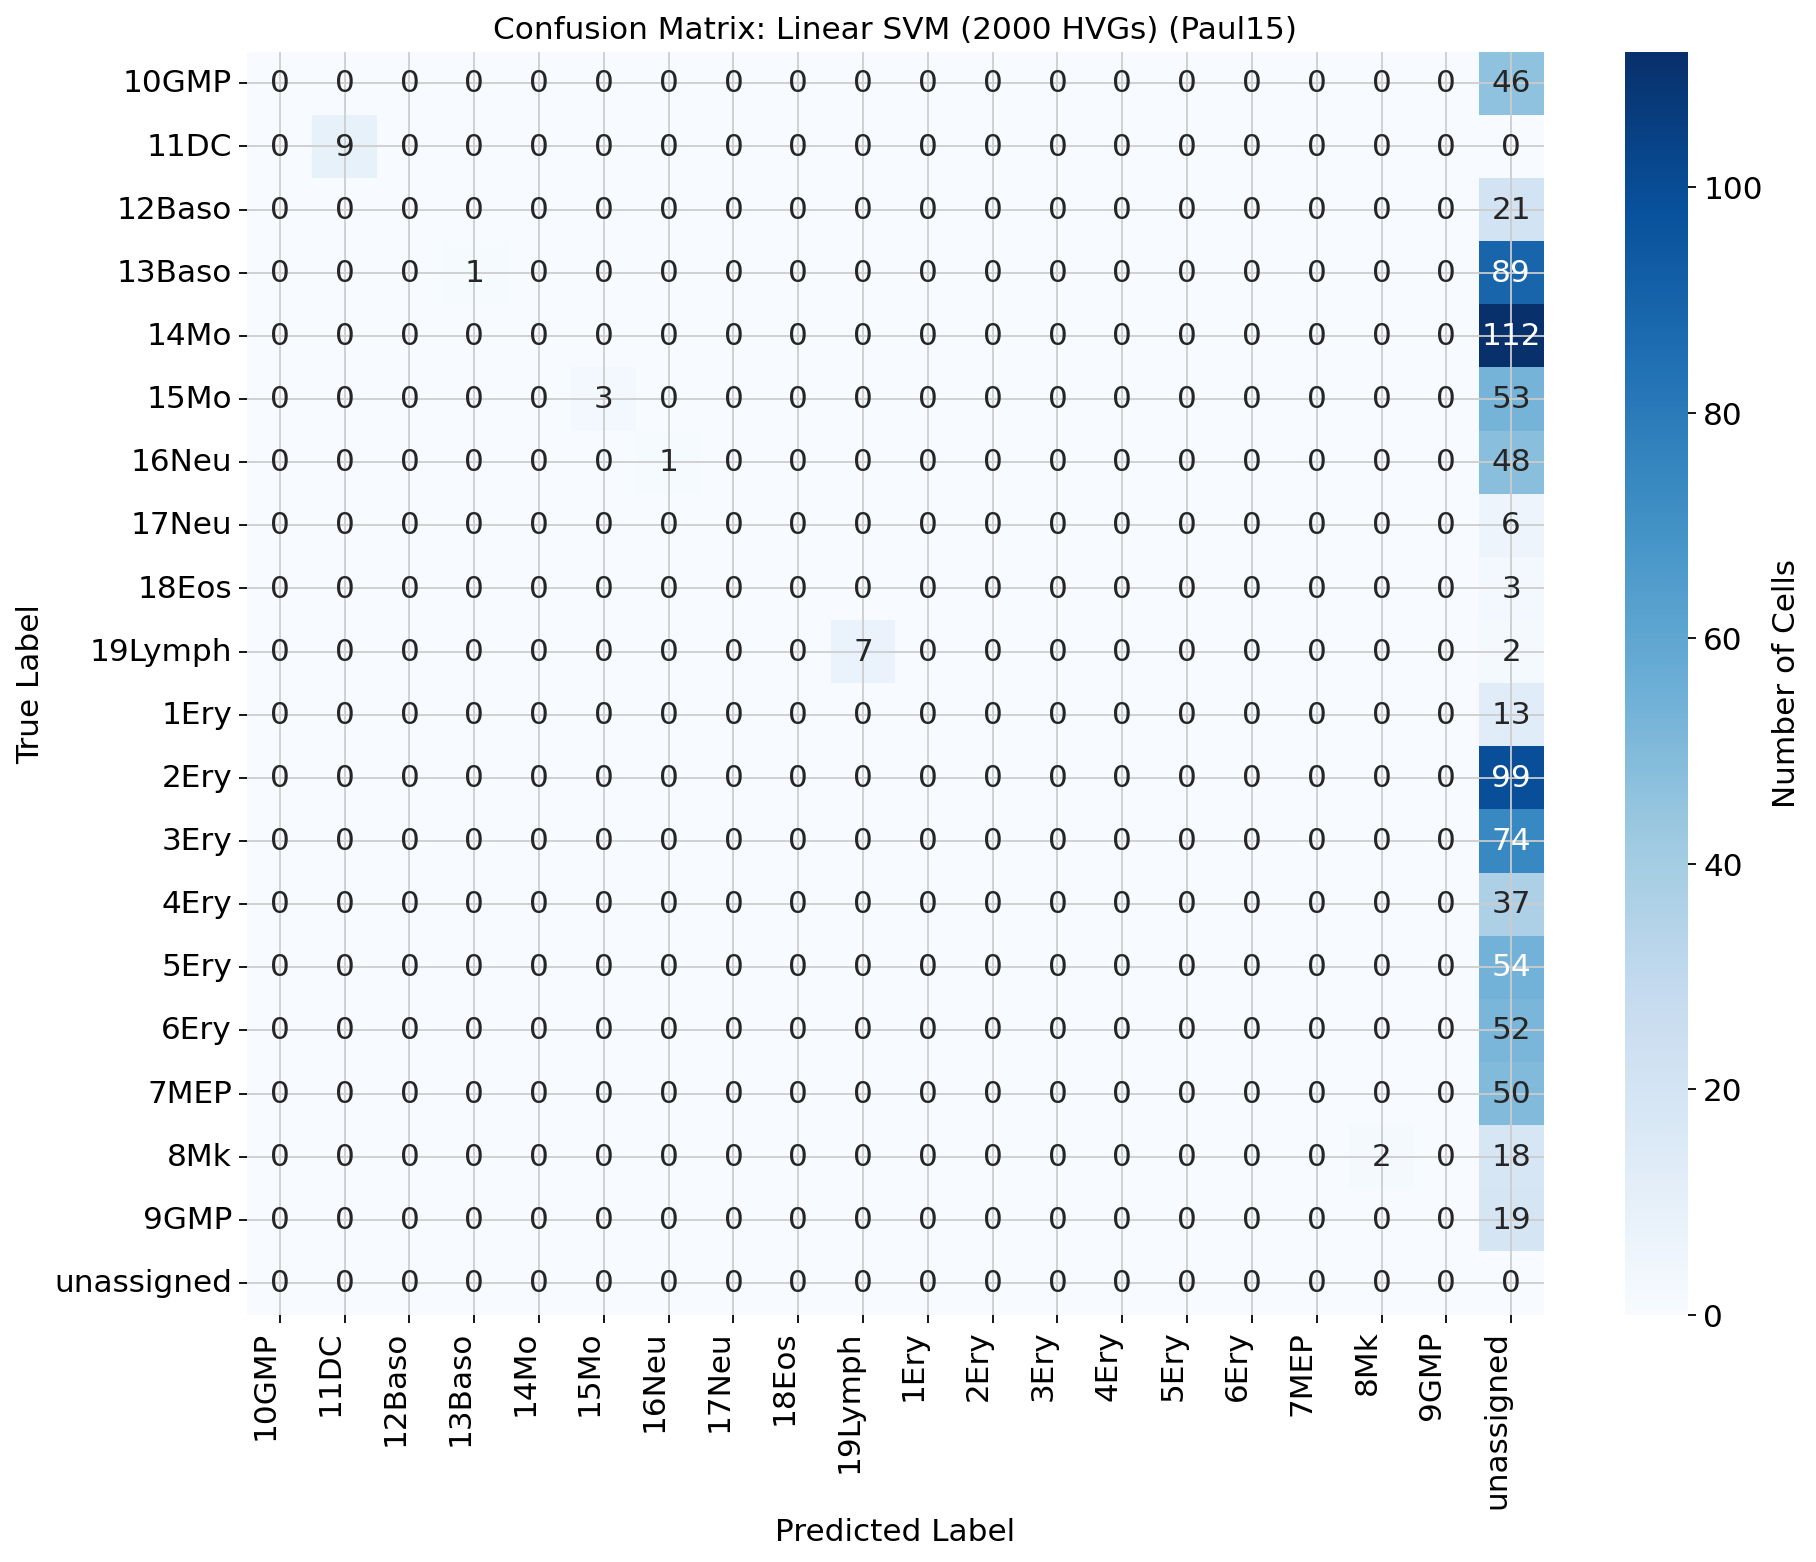


  RUNNING EXPERIMENT: RBF SVM (2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to 2000 reference genes

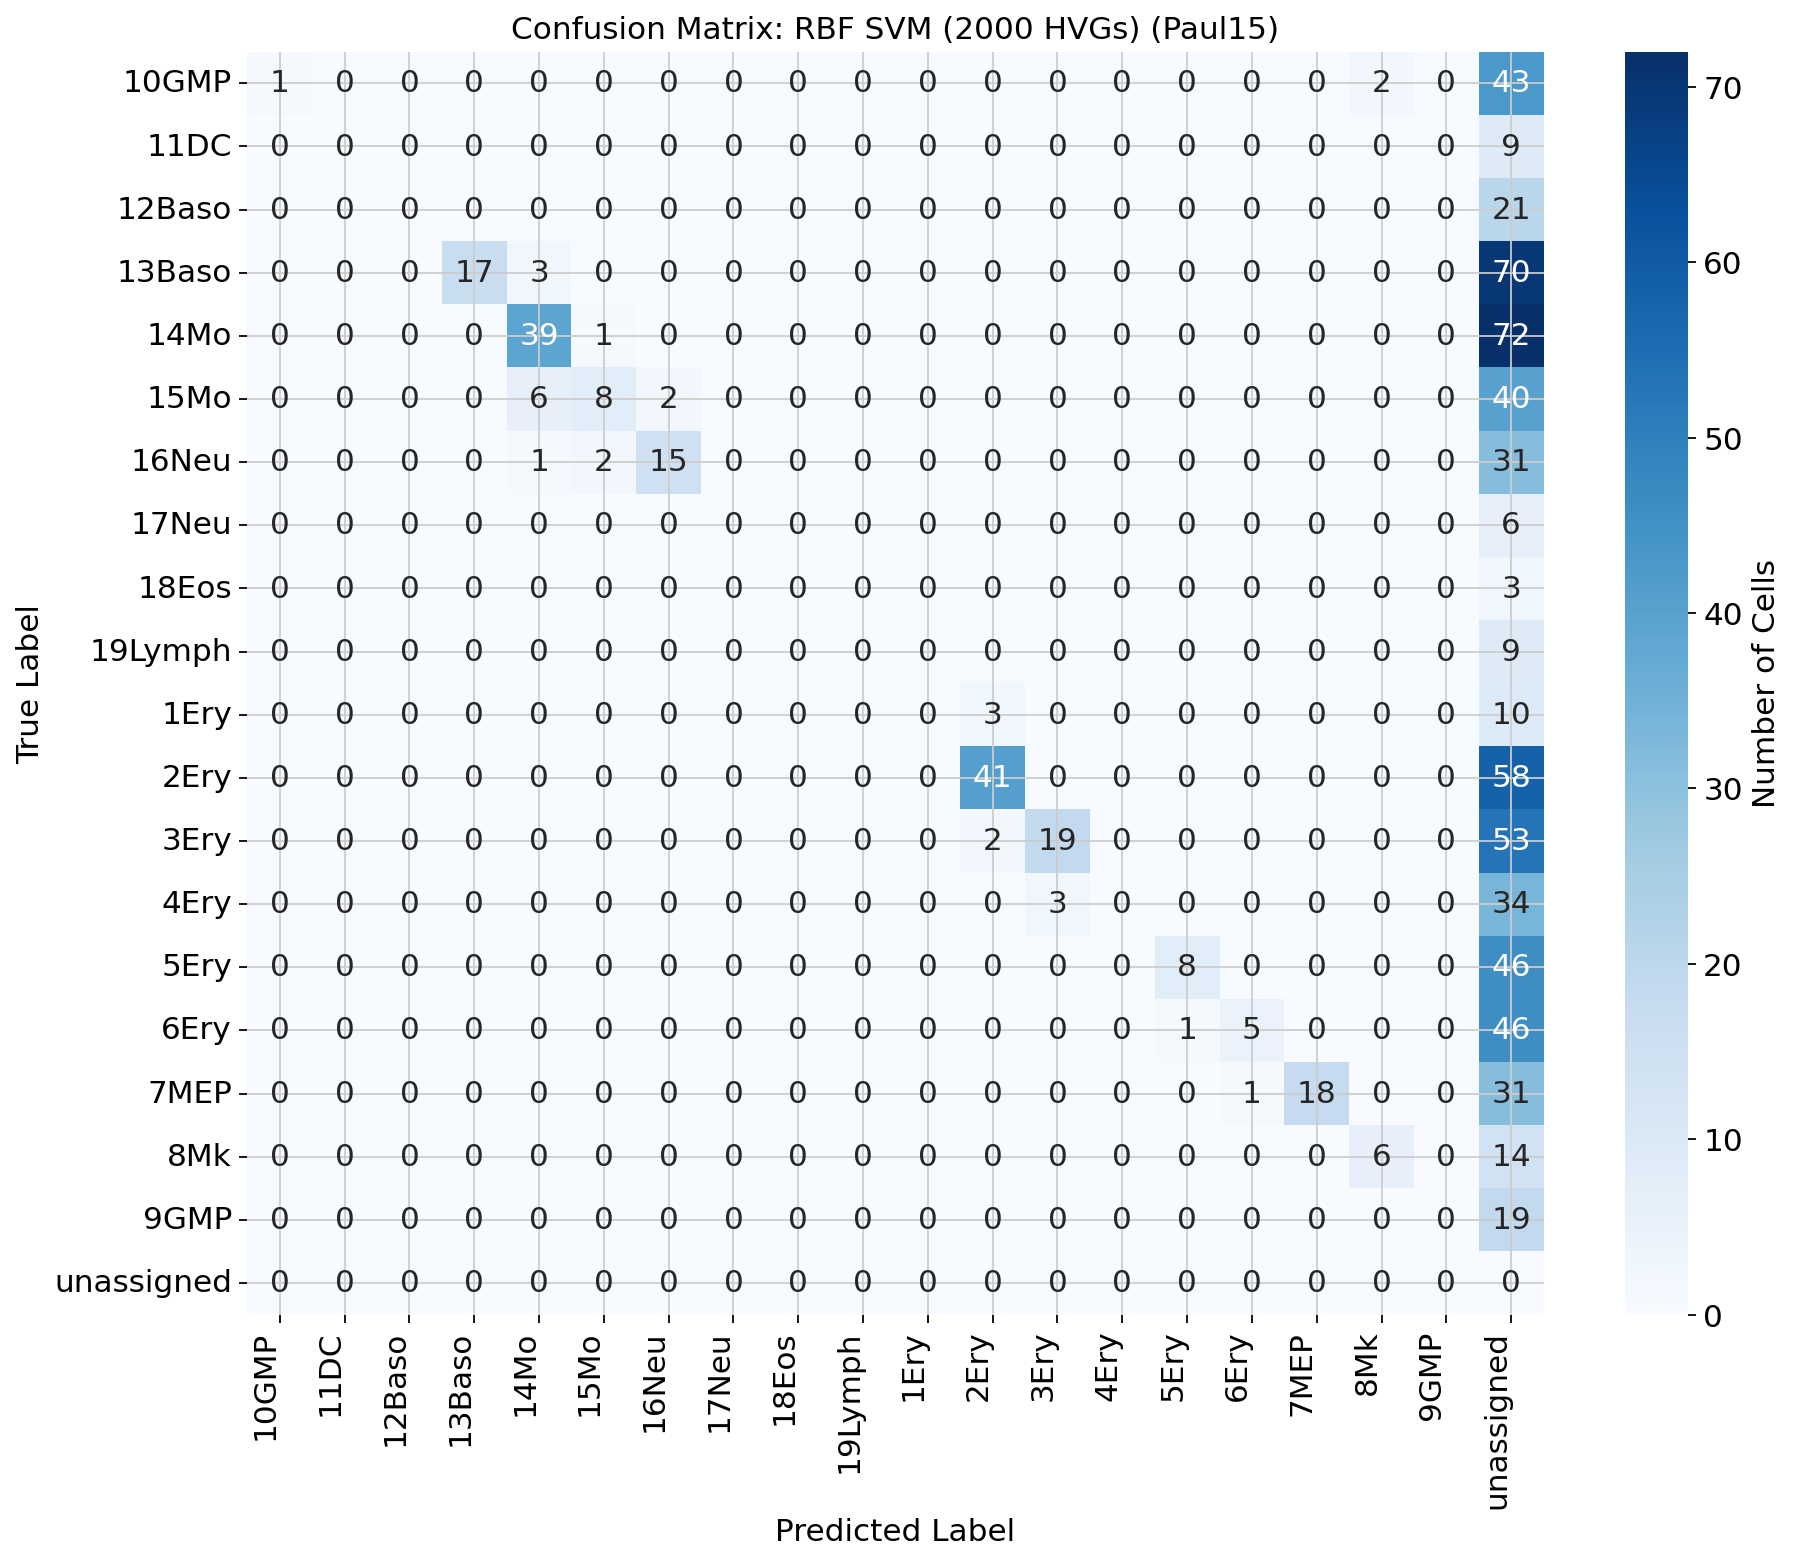


  RUNNING EXPERIMENT: RBF SVM (Balanced, 2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to 2000 r

/home/eva/Class-Project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2776: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Per-class ROC AUC scores:
  Class 10GMP: 1.0000
  Class 11DC: 1.0000
  Class 12Baso: 1.0000
  Class 13Baso: 0.9893
  Class 14Mo: 1.0000
  Class 15Mo: 0.9984
  Class 16Neu: 0.9970
  Class 17Neu: 1.0000
  Class 18Eos: 1.0000
  Class 19Lymph: 1.0000
  Class 1Ery: 0.9729
  Class 2Ery: 0.9860
  Class 3Ery: 0.9974
  Class 4Ery: nan
  Class 5Ery: 0.9974
  Class 6Ery: 0.9818
  Class 7MEP: 1.0000
  Class 8Mk: 1.0000
  Class 9GMP: nan


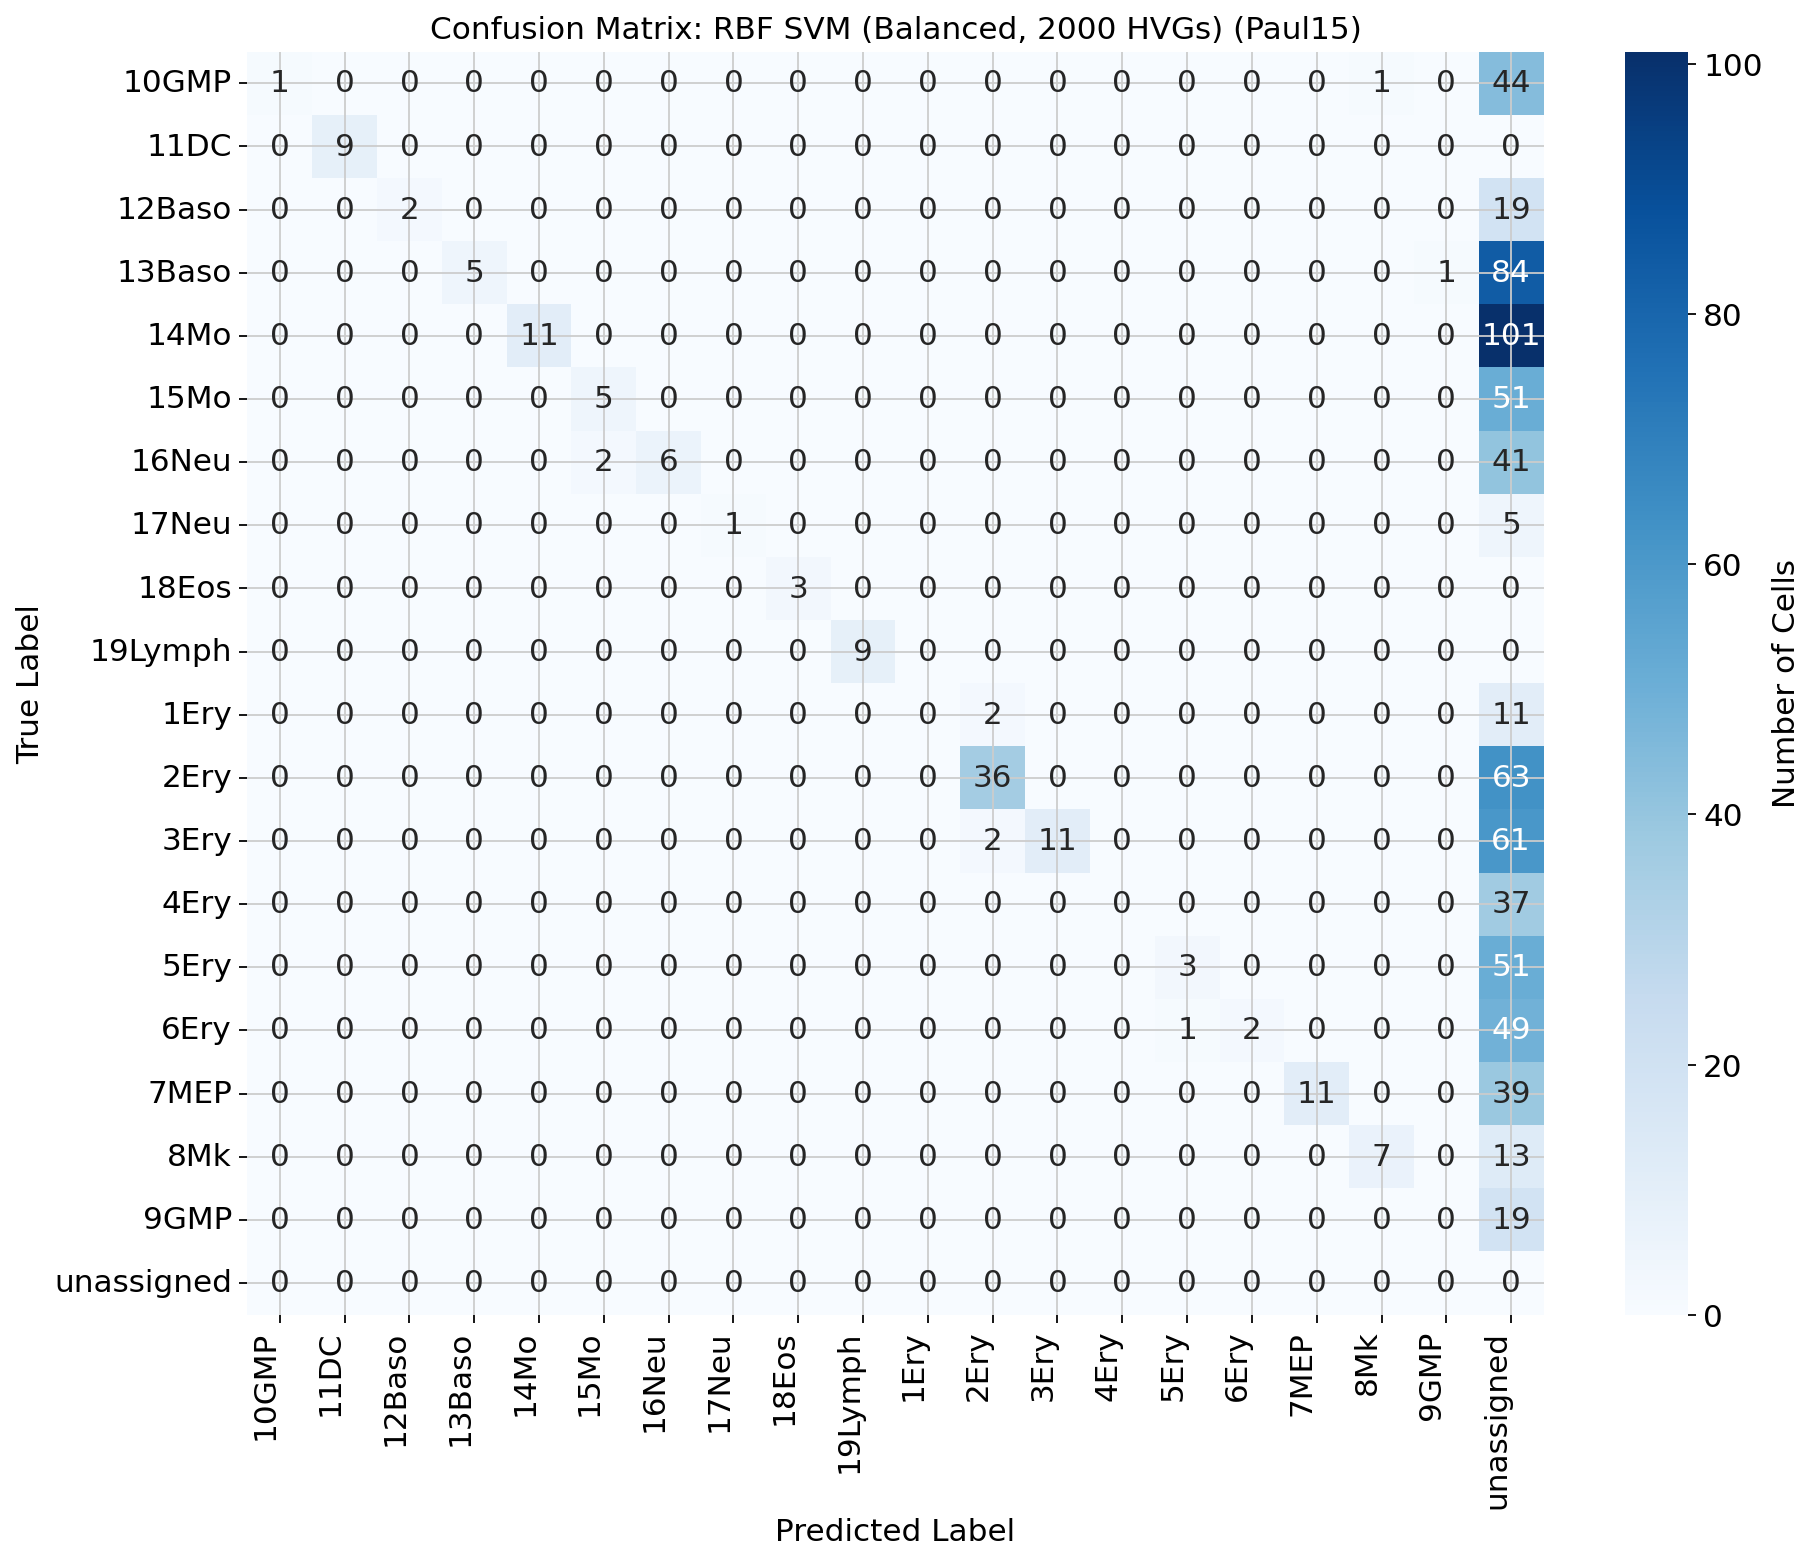


  RUNNING EXPERIMENT: RBF SVM (Balanced, C=10, 2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to

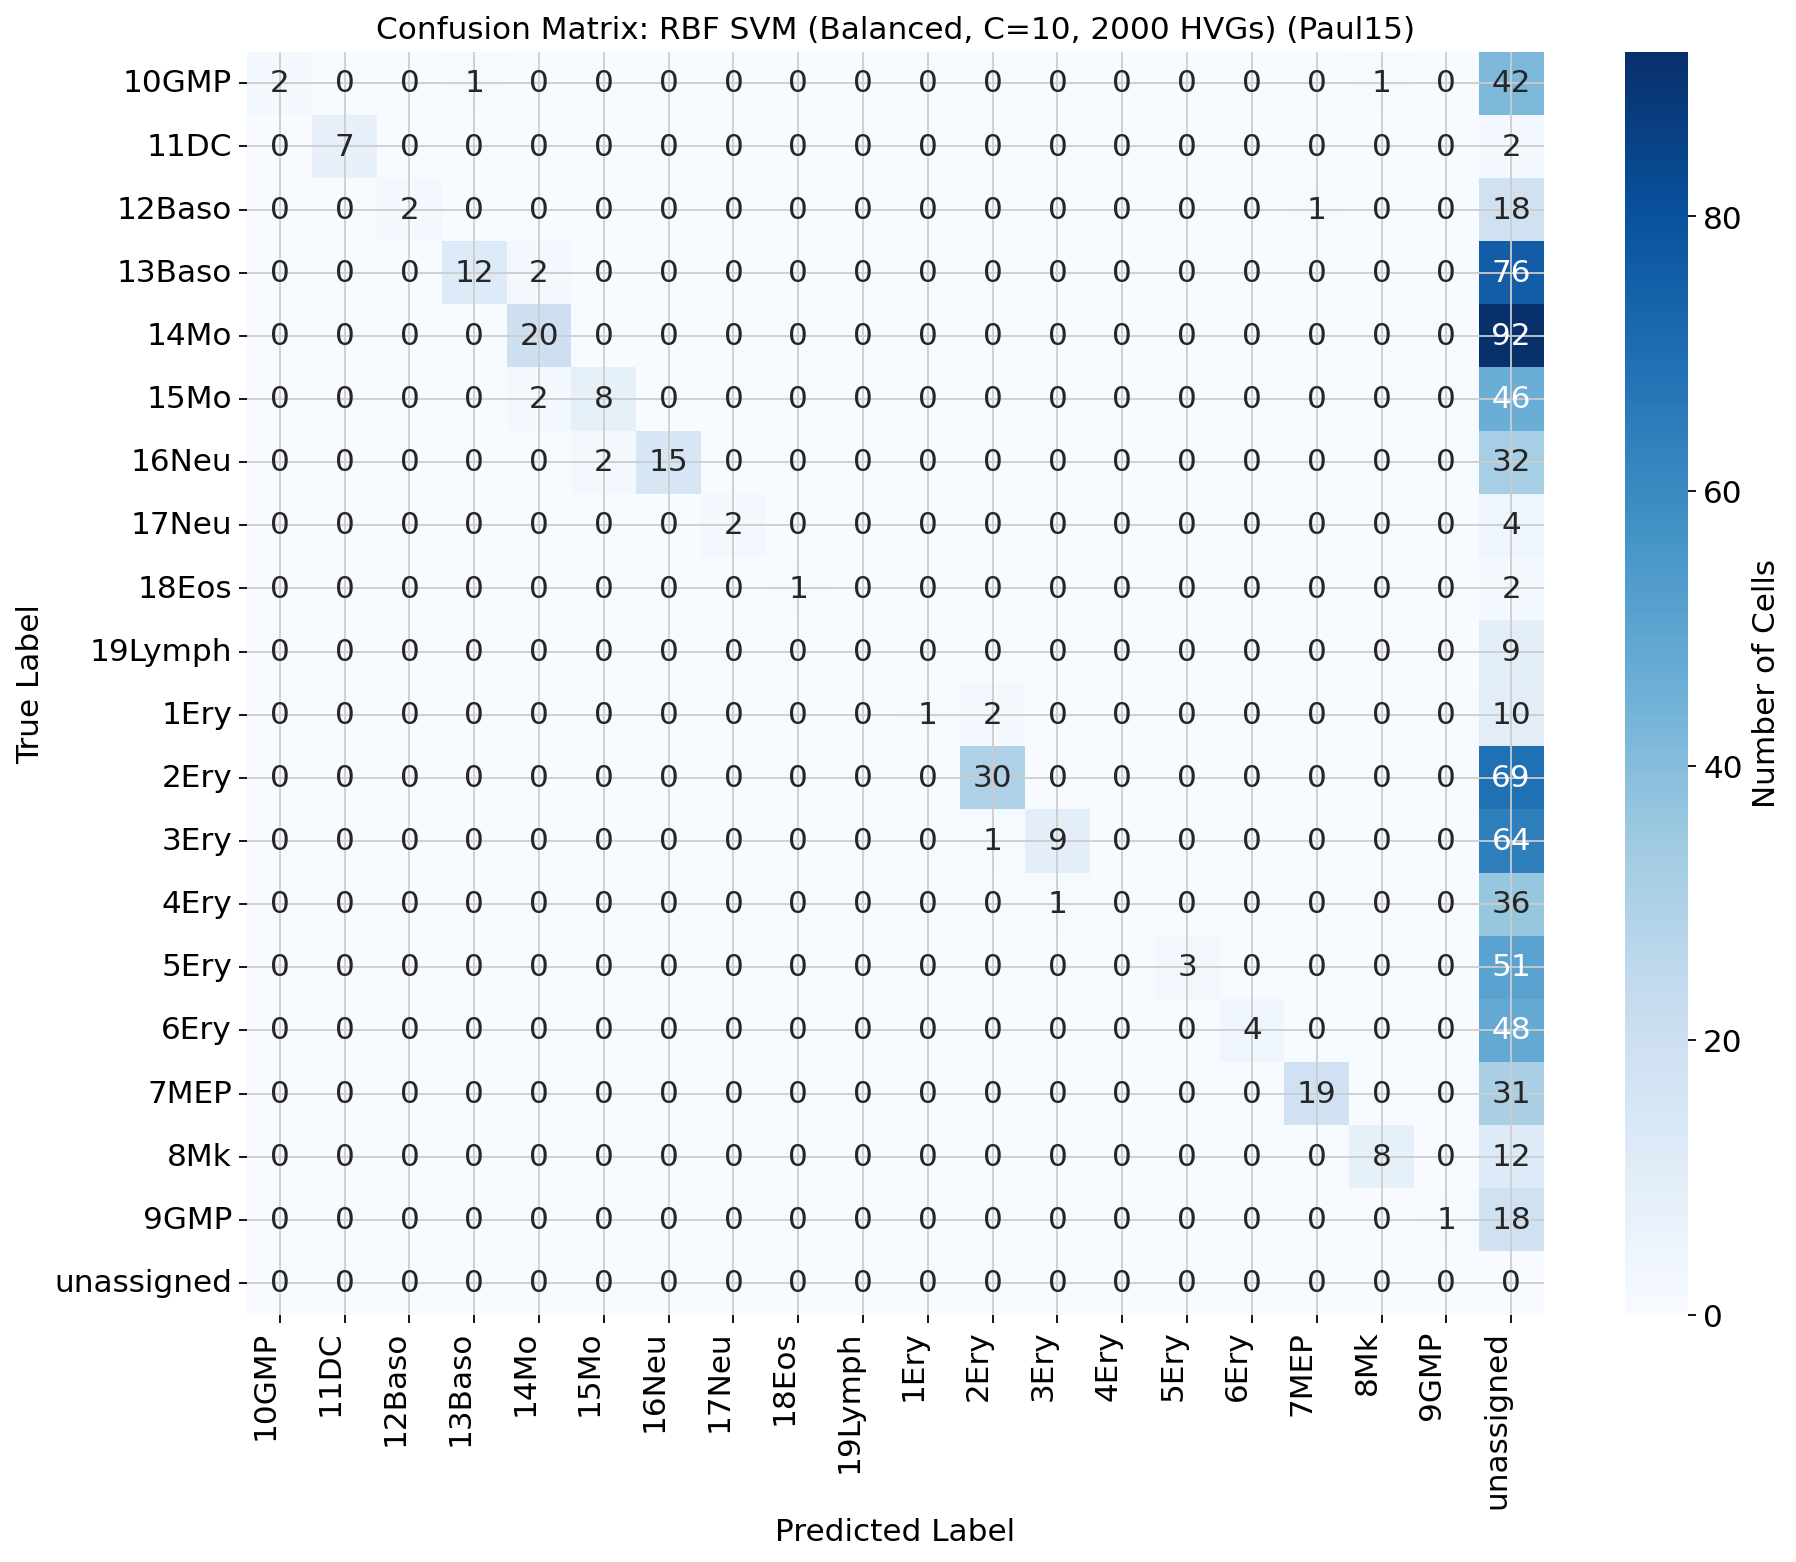



  FINAL RESULTS SUMMARY (paul15)
| Experiment                          |   Overall Accuracy |   Balanced Accuracy |      MCC |
|:------------------------------------|-------------------:|--------------------:|---------:|
| Linear SVM (2000 HVGs)              |                nan |            1        | 1        |
| RBF SVM (2000 HVGs)                 |                nan |            0.705933 | 0.849021 |
| RBF SVM (Balanced, 2000 HVGs)       |                nan |            0.858597 | 0.922451 |
| RBF SVM (Balanced, C=10, 2000 HVGs) |                nan |            0.829972 | 0.908087 |

--- Analysis Complete ---


In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import LabelBinarizer

# Adjust the path to import your package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Importing the main ScPredModel class and utilities
from scpred_py_final import ScPredModel # Adjusted to scpred_py_final as per your package name
from scpred_py_final import _analysis_utils # Assuming _analysis_utils is part of the package


print("--- Setting up environment for reproducibility ---")
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE) # For Python's built-in random module
# Set Scanpy's random state for operations that support it
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(8, 8)) # Set initial figure params

# Define paths for saving (though not directly used in this comparative analysis, good practice)
MODELS_DIR = '../models'
PREPROCESSED_DATA_DIR = '../data/preprocessed'
RAW_DATA_DIR = '../data/raw' # For Paul15 raw data

# Create directories if they don't exist (good practice for consistency)
print(f"Ensuring directories exist: {MODELS_DIR}, {PREPROCESSED_DATA_DIR}, and {RAW_DATA_DIR}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(RAW_DATA_DIR, exist_ok=True) # Ensure raw data directory exists
print("Directories ensured.")


# --- 1. Data Loading and Annotation (Paul15) ---
print("\n--- Step 1: Loading and Annotating Paul15 Data ---")

# Load Paul15 dataset
# Assuming 'paul15_data.h5ad' is in the '../data/raw/' directory.
# If you have your Paul15 data in a different format or location, adjust this line.
try:
    adata = sc.read_h5ad(os.path.join(RAW_DATA_DIR, 'paul15_data.h5ad'))
    print(f"Loaded Paul15 data from: {os.path.join(RAW_DATA_DIR, 'paul15_data.h5ad')}")
except FileNotFoundError:
    print(f"Warning: 'paul15_data.h5ad' not found in {RAW_DATA_DIR}. Attempting to load from Scanpy datasets if available.")
    # Fallback to a Scanpy dataset if a direct file isn't found.
    try:
        adata = sc.datasets.paul15()
        print("Loaded Paul15 data using sc.datasets.paul15().")
    except Exception as e:
        raise RuntimeError(f"Could not load Paul15 data. Please ensure 'paul15_data.h5ad' is in {RAW_DATA_DIR} or adjust the loading path. Error: {e}")

adata.var_names_make_unique()

# Ensure 'cell_type' column is present and categorical.
# Paul15 dataset often comes with 'paul15_clusters' or similar.
if 'paul15_clusters' in adata.obs.keys():
    adata.obs['cell_type'] = adata.obs['paul15_clusters'].astype('category')
    print("Assigned 'paul15_clusters' to 'cell_type' column.")
elif 'cell_type' in adata.obs.keys():
    adata.obs['cell_type'] = adata.obs['cell_type'].astype('category')
    print("Using existing 'cell_type' column.")
else:
    # If no 'paul15_clusters' or 'cell_type' exists, generate temporary labels via Louvain
    print("Warning: 'paul15_clusters' or 'cell_type' not found. Generating temporary labels via Louvain clustering...")
    temp_adata_for_labels = adata.copy()
    sc.pp.filter_cells(temp_adata_for_labels, min_genes=200)
    sc.pp.filter_genes(temp_adata_for_labels, min_cells=3)
    sc.pp.normalize_total(temp_adata_for_labels, target_sum=1e4)
    sc.pp.log1p(temp_adata_for_labels)
    sc.pp.highly_variable_genes(temp_adata_for_labels, min_mean=0.0125, max_mean=3, min_disp=0.5, flavor='seurat')
    temp_adata_hvg_for_labels = temp_adata_for_labels[:, temp_adata_for_labels.var.highly_variable].copy()
    sc.pp.scale(temp_adata_hvg_for_labels, max_value=10)
    sc.tl.pca(temp_adata_hvg_for_labels, svd_solver='arpack', random_state=RANDOM_STATE)
    sc.pp.neighbors(temp_adata_hvg_for_labels, n_neighbors=10, n_pcs=40, random_state=RANDOM_STATE)
    sc.tl.louvain(temp_adata_hvg_for_labels, random_state=RANDOM_STATE, key_added='cell_type')
    adata.obs['cell_type'] = temp_adata_hvg_for_labels.obs['cell_type'].reindex(adata.obs_names).astype('category')
    print("Generated temporary cell type labels.")

print(f"Full dataset (raw counts + labels) shape: {adata.shape}")
print(f"Full dataset .obs keys after labeling: {adata.obs.keys().tolist()}")
print("Cell type distribution (all data):\n", adata.obs['cell_type'].value_counts())
print("Data loading and labeling complete.")


# --- 2. Train-Test Split ---
print("\n--- Step 2: Splitting Data ---")
indices = range(adata.n_obs)
ref_idx, query_idx = train_test_split(
    indices, test_size=0.3, random_state=RANDOM_STATE, stratify=adata.obs['cell_type']
)
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()
print("Data splitting complete.")


# Calculate and report class imbalance
print("\n--- Class Imbalance Analysis ---")
print("Reference data class imbalance (proportion):\n", ref_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())
print("Query data class imbalance (proportion):\n", query_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())


# --- 3. Define the Experiment Runner Function ---
def run_scpred_experiment(experiment_name, ref_data, query_data, hvg_n_top_genes, svm_params, prediction_threshold=0.8):
    """
    A helper function to run a single scPred experiment with given parameters.
    Includes prediction threshold and passes probabilities for ROC AUC.
    """
    print("\n" + "="*50)
    print(f"  RUNNING EXPERIMENT: {experiment_name}")
    print("="*50)
    
    # --- Train Model ---
    model = ScPredModel()
    model.train(
        ref_adata=ref_data,
        cell_type_key='cell_type',
        n_components=30,
        hvg_n_top_genes=hvg_n_top_genes, # Pass HVGs as parameter
        hvg_flavor='seurat',  # Use 'seurat' flavor consistently
        **svm_params          # Pass all SVM parameters including class_weight
    )
    
    # --- Predict ---
    # FIX: Pass prediction_threshold to model.predict
    query_pred = model.predict(query_data, threshold=prediction_threshold)
    
    # --- Evaluate ---
    true_labels = query_pred.obs['cell_type']
    predicted_labels = query_pred.obs['scpred_prediction']
    
    # Extract prediction probabilities for ROC AUC
    # Ensure these columns exist before trying to copy
    prob_cols = [col for col in query_pred.obs.columns if col.startswith('scpred_prob_')]
    y_pred_probs_df = None
    if prob_cols: # Check if the list is not empty
        y_pred_probs_df = query_pred.obs[prob_cols].copy()

    print(f"\n--- Results for: {experiment_name} ---")
    
    # Use the analysis util for the full report, passing y_pred_probs for ROC AUC
    metrics = _analysis_utils.evaluate_and_report_metrics(
        true_labels=true_labels,
        predicted_labels=predicted_labels,
        classifier_classes=model.classifier_.classes_, # Pass classifier classes
        y_pred_probs=y_pred_probs_df # Pass probabilities
    )
    
    # --- Visualize Confusion Matrix ---
    # Ensure labels are string type consistently, including "unassigned" if present
    true_labels_str = true_labels.astype(str)
    predicted_labels_str = predicted_labels.astype(str)

    # Ensure all unique labels (true and predicted, including 'unassigned') are used for CM labels
    cm_labels_str = sorted(list(set(true_labels_str.unique()) | set(predicted_labels_str.unique())))
    cm = confusion_matrix(true_labels_str, predicted_labels_str, labels=cm_labels_str)
    cm_df = pd.DataFrame(cm, index=cm_labels_str, columns=cm_labels_str)
    
    plt.figure(figsize=(12, 10)) # Increased size for more classes
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Cells'})
    plt.title(f'Confusion Matrix: {experiment_name} (Paul15)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=90, ha='right') # Rotate x-axis labels for Paul15
    plt.yticks(rotation=0) # Keep y-axis labels horizontal
    plt.tight_layout()
    plt.show()
    
    return {
        "Experiment": experiment_name,
        "Overall Accuracy": metrics.get('overall_accuracy', np.nan), # Use overall_accuracy from metrics
        "Balanced Accuracy": metrics.get('balanced_accuracy', np.nan),
        "MCC": metrics.get('mcc', np.nan),
        "ROC AUC Scores": metrics.get('roc_auc_scores', {}) # Include ROC AUC scores
    }


# --- 4. Run Comparative Experiments ---
print("\n\n--- Step 4: Running Comparative Analyses on paul15 ---")

# For Paul15, let's try more HVGs and a higher C value for the RBF kernel
# to see if it can handle the increased complexity.
experiments_to_run_paul15 = {
    "Linear SVM (2000 HVGs)": {
        'svm_kernel': 'linear', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'class_weight': None
    },
    "RBF SVM (2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'class_weight': None
    },
    "RBF SVM (Balanced, 2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'class_weight': 'balanced'
    },
    "RBF SVM (Balanced, C=10, 2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 10.0, 'svm_random_state': RANDOM_STATE, 'class_weight': 'balanced'
    }
}

results_list_paul15 = []
for name, params in experiments_to_run_paul15.items():
    # Pass 2000 HVGs for all paul15 experiments and a prediction threshold
    result = run_scpred_experiment(name, ref_adata_raw.copy(), query_adata_raw.copy(), 2000, params, prediction_threshold=0.8)
    results_list_paul15.append(result)


# --- 5. Summarize Results ---
print("\n\n" + "="*50)
print("  FINAL RESULTS SUMMARY (paul15)")
print("="*50)

results_df_paul15 = pd.DataFrame(results_list_paul15)
# Display ROC AUC scores separately or as a nested dict if desired
# For a clean markdown table, we'll just show the main metrics.
# You can inspect results_list_paul15 for the full ROC AUC dicts.
print(results_df_paul15[['Experiment', 'Overall Accuracy', 'Balanced Accuracy', 'MCC']].to_markdown(index=False))

print("\n--- Analysis Complete ---")

--- Setting up environment for reproducibility ---
Ensuring directories exist: ../models, ../data/preprocessed, and ../data/raw
Directories ensured.

--- Step 1: Loading and Annotating Paul15 Data ---
Loaded Paul15 data using sc.datasets.paul15().
Assigned 'paul15_clusters' to 'cell_type' column.
Full dataset (raw counts + Paul15 clusters) shape: (2730, 3451)
Full dataset .obs keys after labeling: ['paul15_clusters', 'cell_type']
Cell type distribution (all data):
 cell_type
14Mo       373
2Ery       329
13Baso     300
3Ery       246
15Mo       186
5Ery       180
6Ery       173
7MEP       167
16Neu      164
10GMP      153
4Ery       124
12Baso      69
8Mk         68
9GMP        63
1Ery        43
19Lymph     31
11DC        30
17Neu       22
18Eos        9
Name: count, dtype: int64
Data loading and labeling complete.

--- Step 2: Splitting Data ---
Data splitting complete.

--- Class Imbalance Analysis ---
Reference data class imbalance (proportion):
 cell_type
1Ery       0.015699
2Ery  

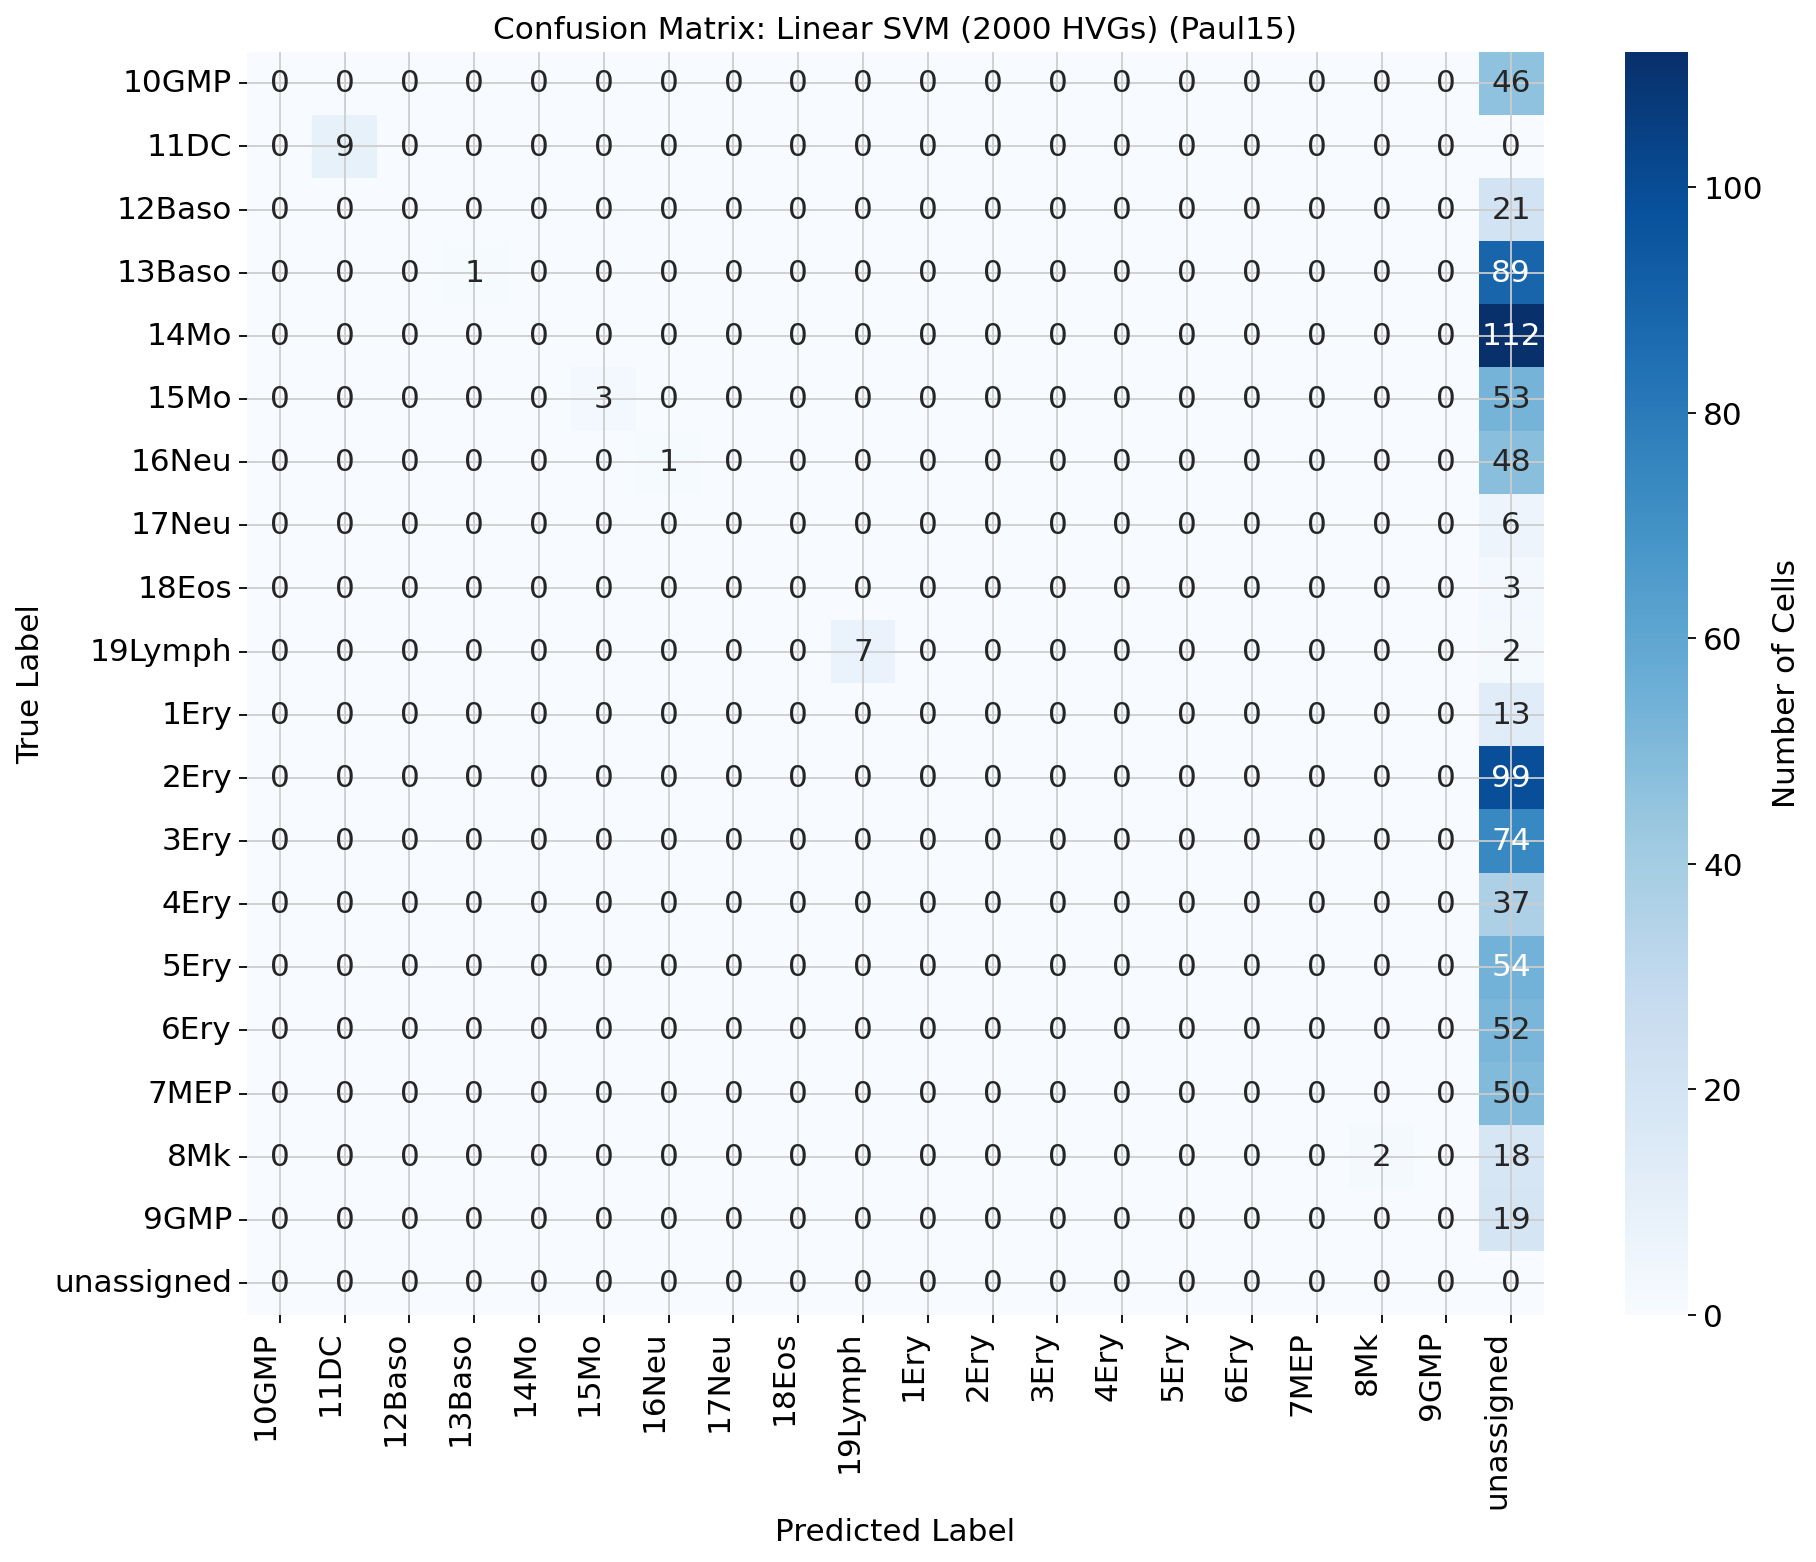


  RUNNING EXPERIMENT: RBF SVM (2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to 2000 reference genes

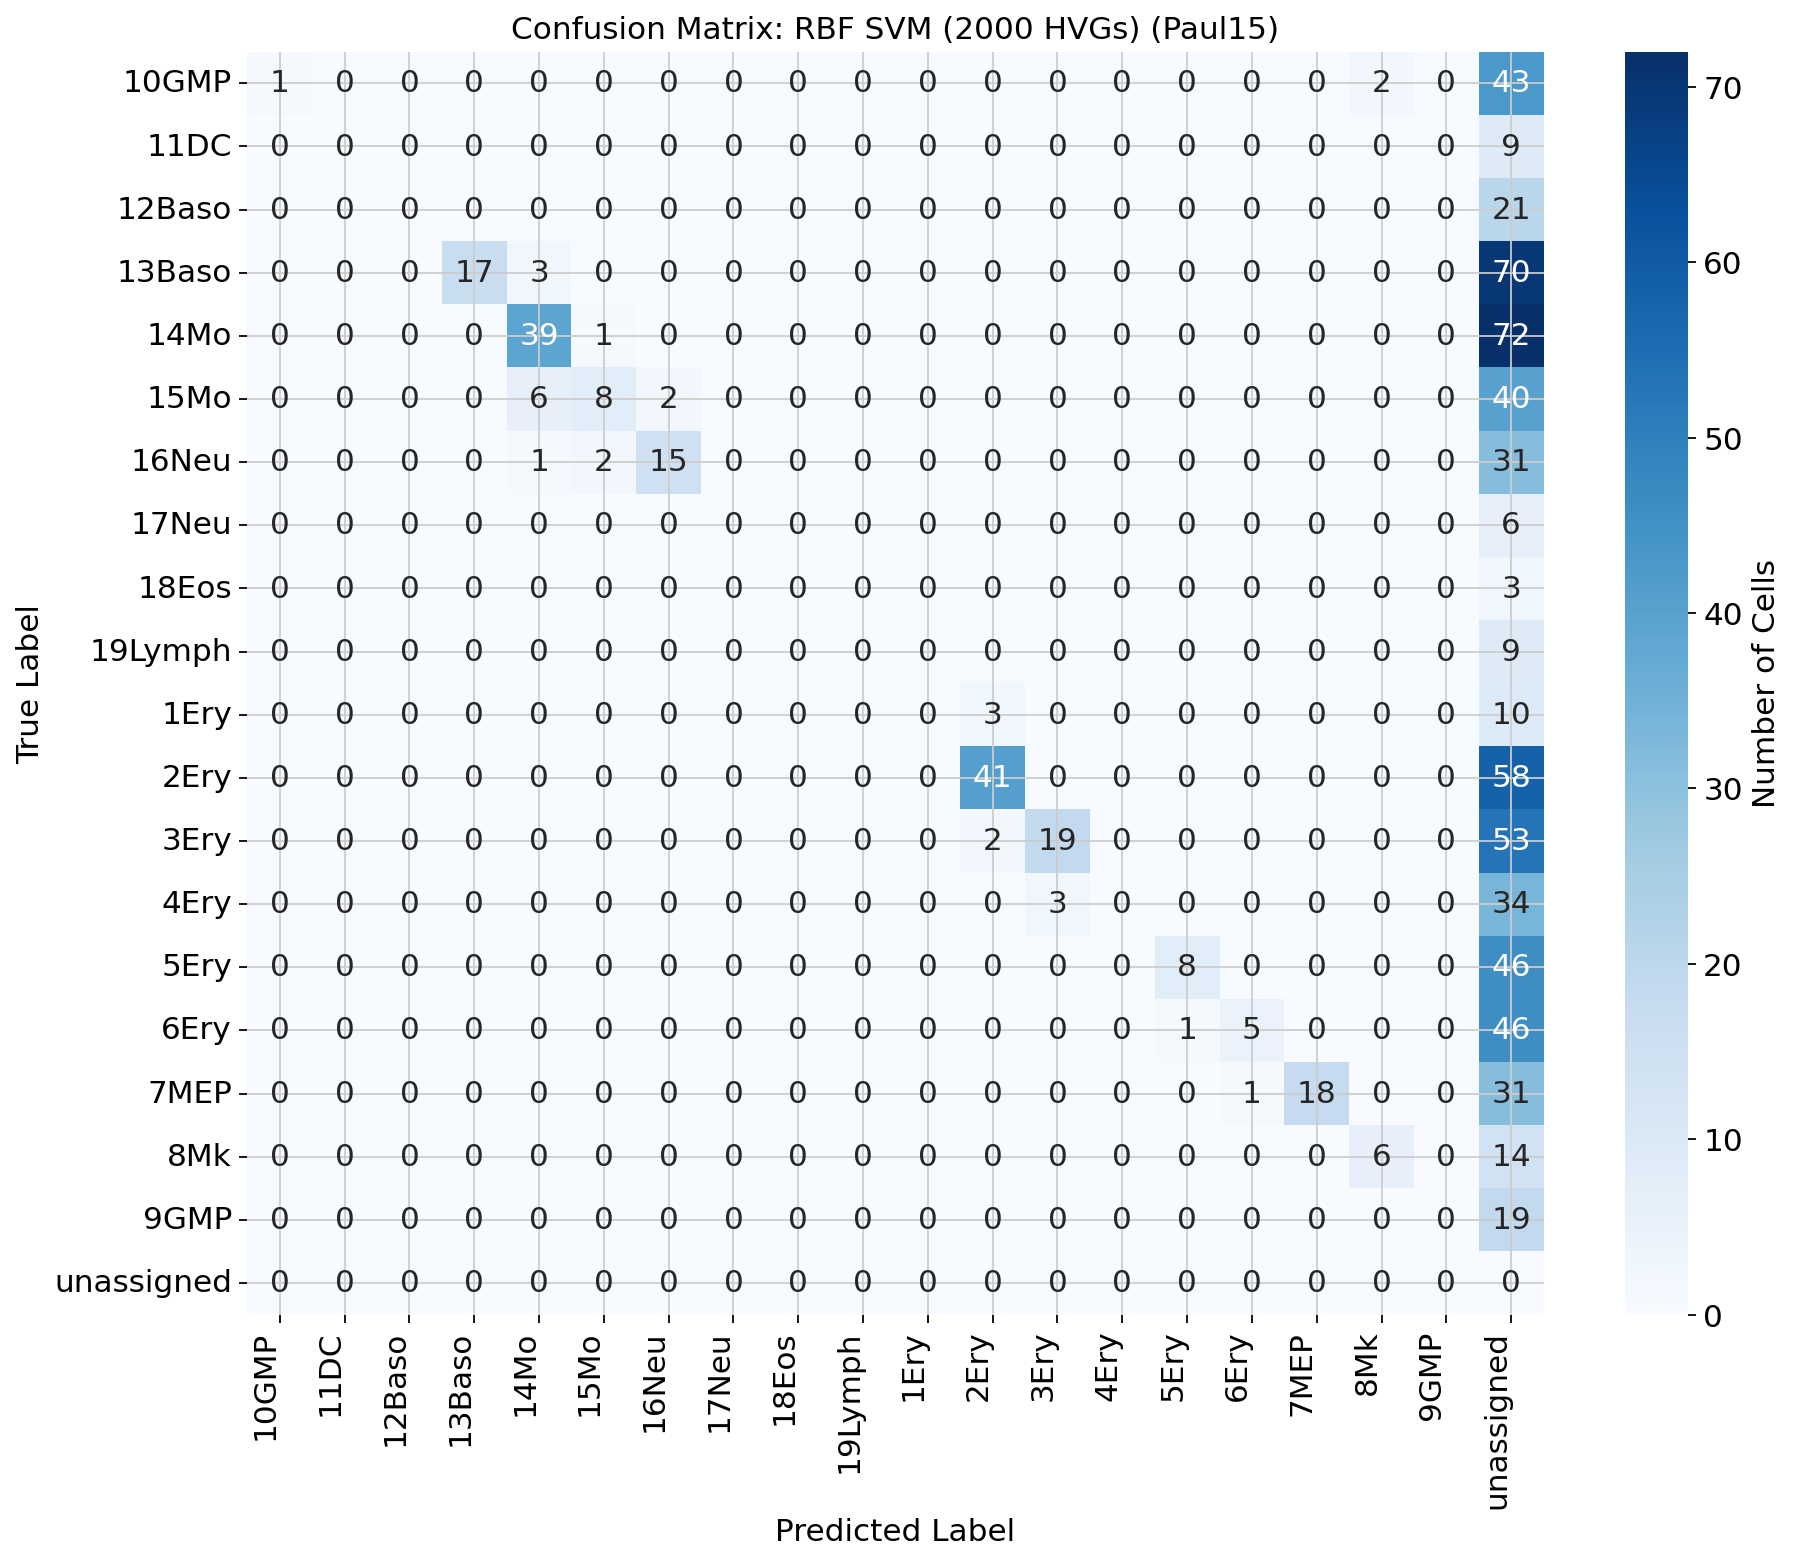


  RUNNING EXPERIMENT: RBF SVM (Balanced, 2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to 2000 r

/home/eva/Class-Project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2776: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Per-class ROC AUC scores:
  Class 10GMP: 1.0000
  Class 11DC: 1.0000
  Class 12Baso: 1.0000
  Class 13Baso: 0.9893
  Class 14Mo: 1.0000
  Class 15Mo: 0.9984
  Class 16Neu: 0.9970
  Class 17Neu: 1.0000
  Class 18Eos: 1.0000
  Class 19Lymph: 1.0000
  Class 1Ery: 0.9729
  Class 2Ery: 0.9860
  Class 3Ery: 0.9974
  Class 4Ery: nan
  Class 5Ery: 0.9974
  Class 6Ery: 0.9818
  Class 7MEP: 1.0000
  Class 8Mk: 1.0000
  Class 9GMP: nan


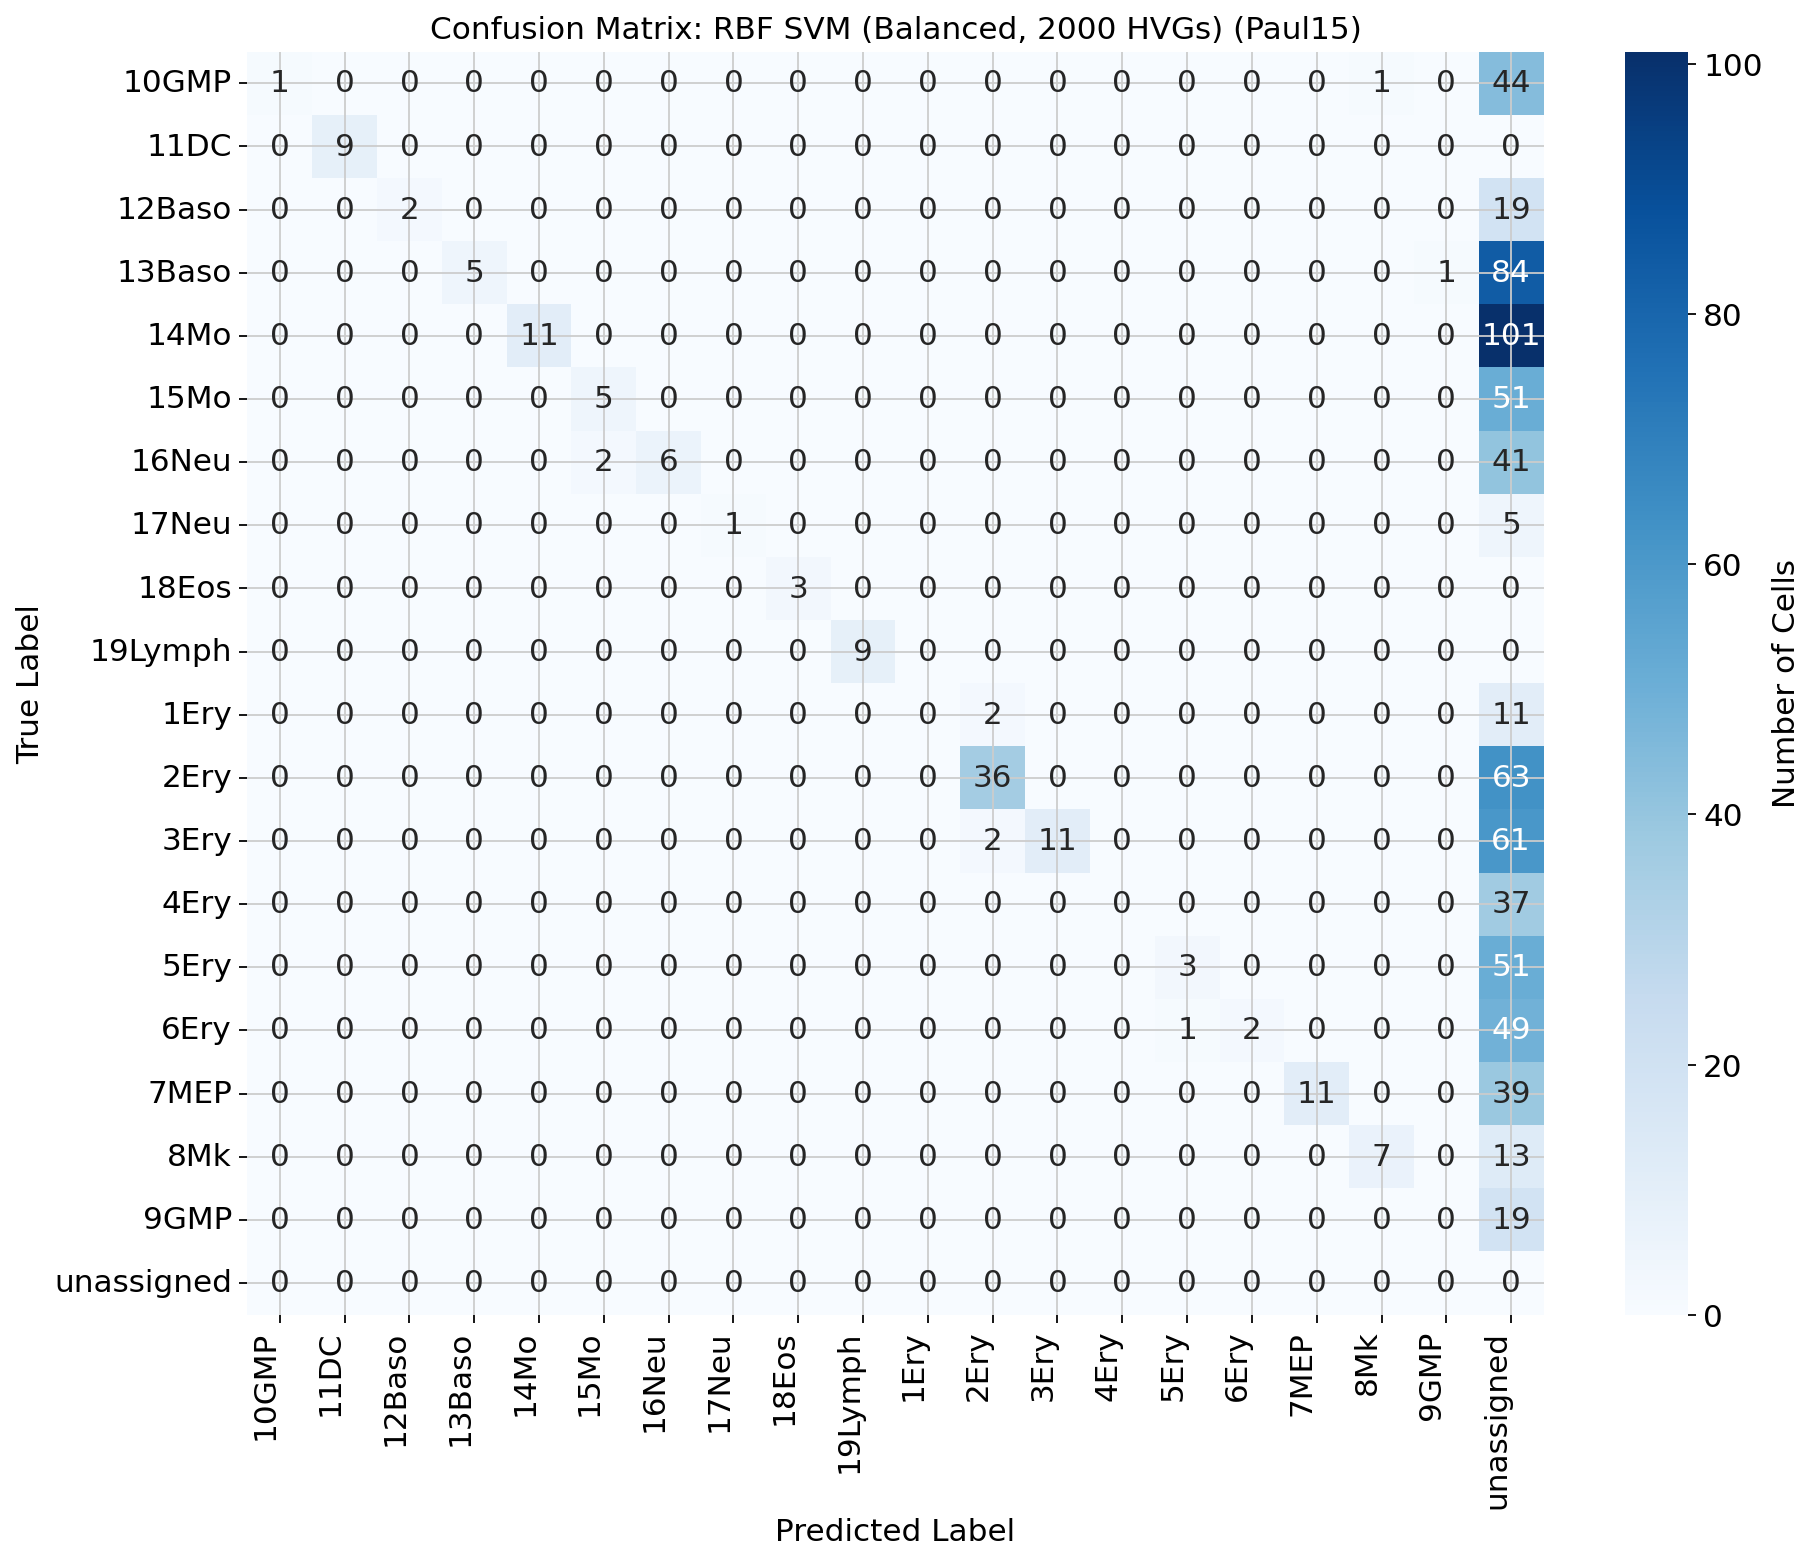


  RUNNING EXPERIMENT: RBF SVM (Balanced, C=10, 2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to

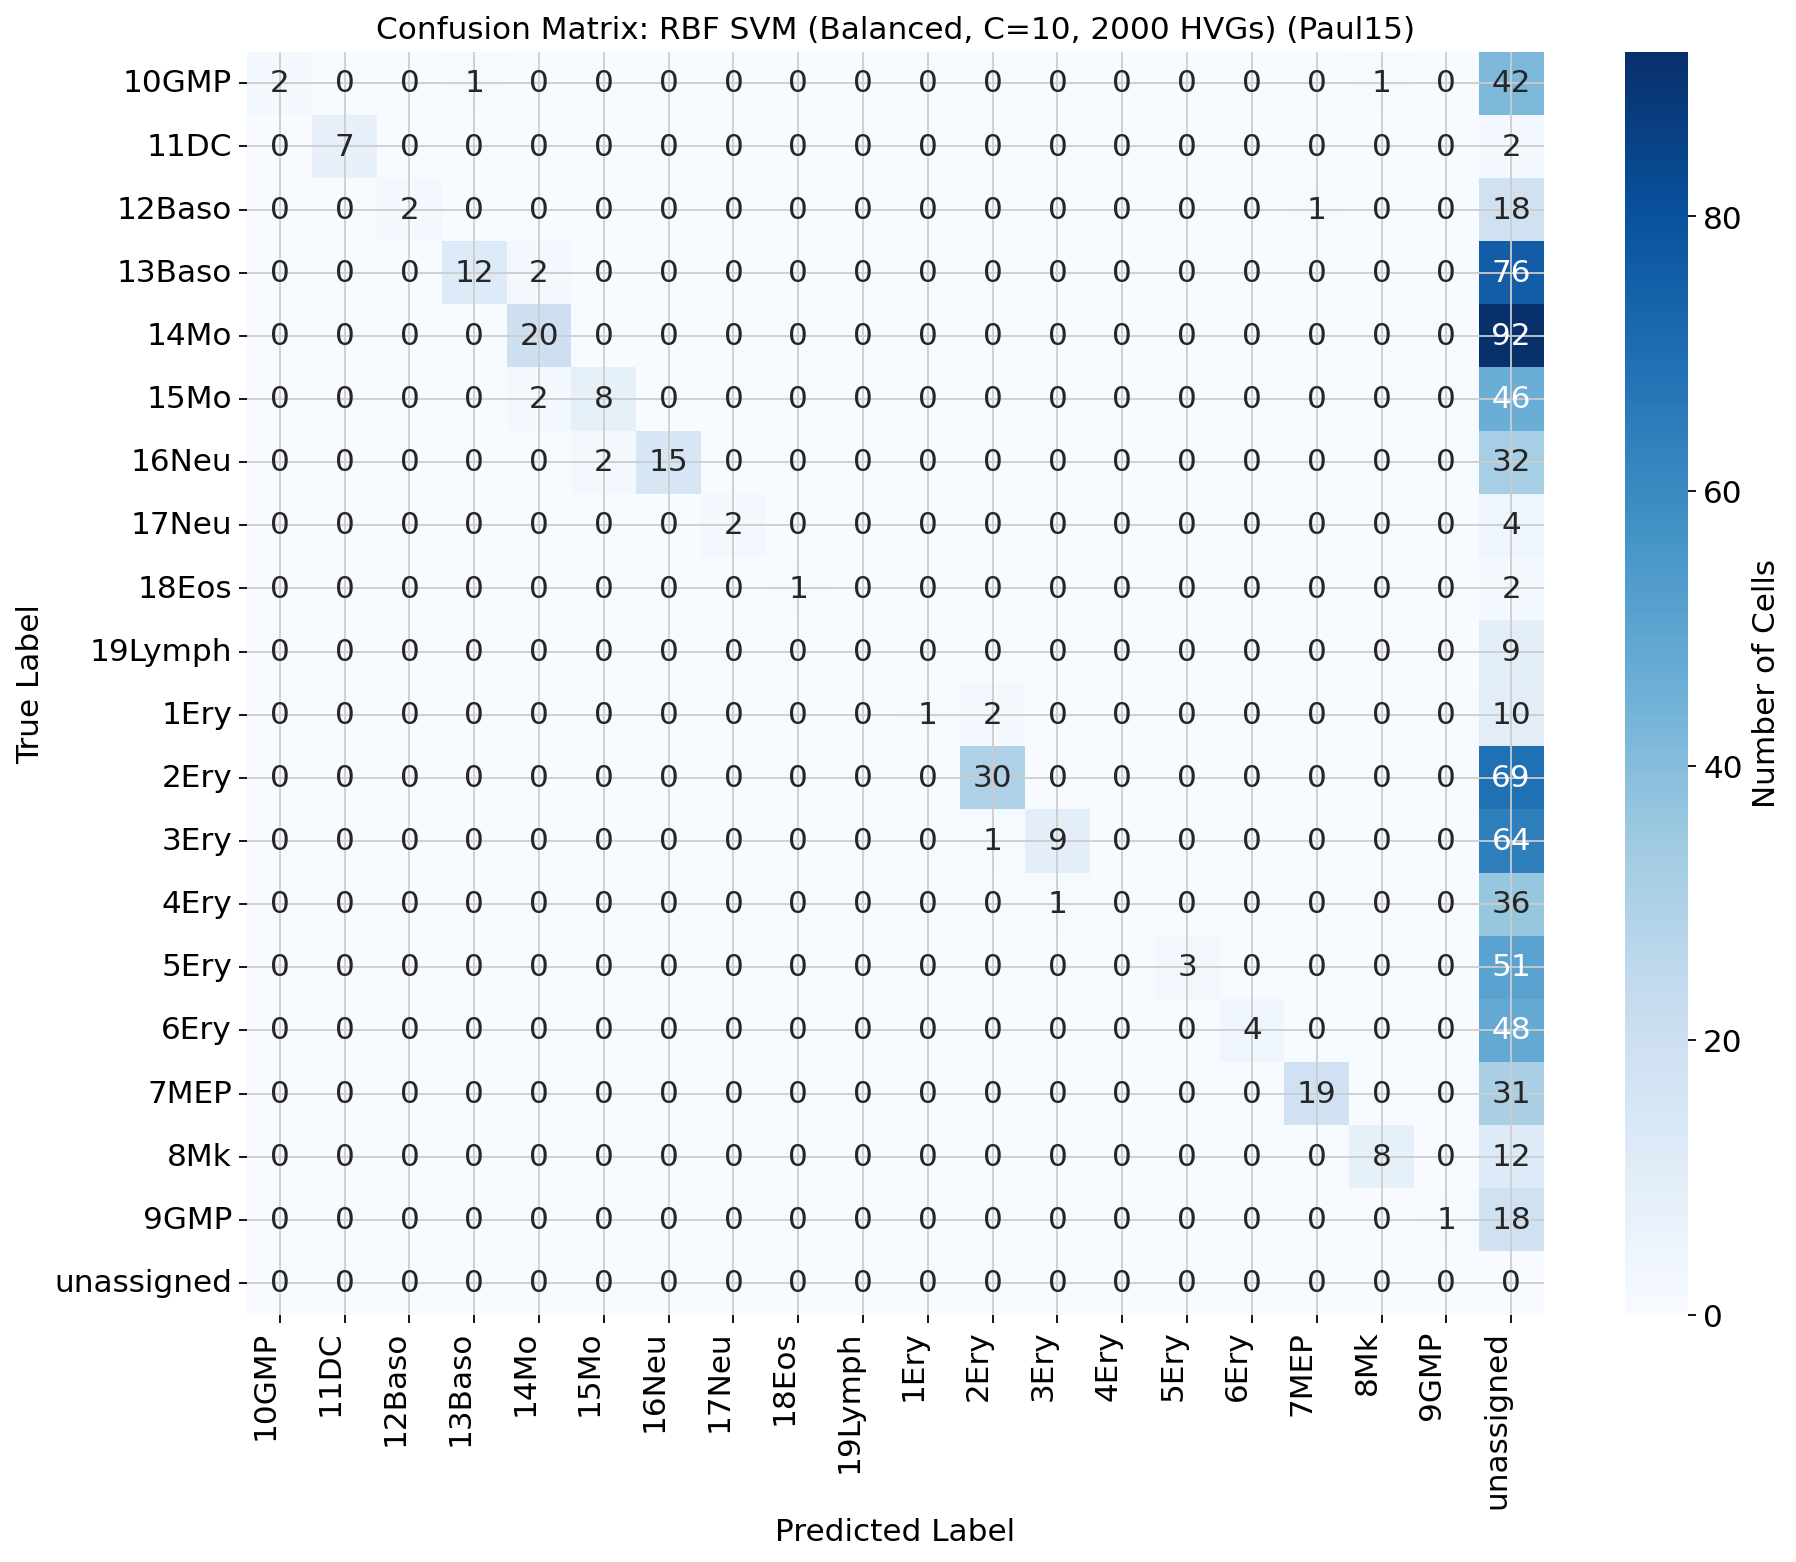



  FINAL RESULTS SUMMARY (paul15)
| Experiment                          |   Overall Accuracy |   Balanced Accuracy |      MCC |
|:------------------------------------|-------------------:|--------------------:|---------:|
| Linear SVM (2000 HVGs)              |           0.028083 |            1        | 1        |
| RBF SVM (2000 HVGs)                 |           0.216117 |            0.705933 | 0.849021 |
| RBF SVM (Balanced, 2000 HVGs)       |           0.148962 |            0.858597 | 0.922451 |
| RBF SVM (Balanced, C=10, 2000 HVGs) |           0.175824 |            0.829972 | 0.908087 |

--- Analysis Complete ---


In [2]:
# --- 0. Imports and Setup ---
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score, # Import accuracy_score for overall accuracy
    balanced_accuracy_score, # For balanced accuracy
    matthews_corrcoef # For MCC
)
from sklearn.preprocessing import LabelBinarizer

# Adjust the path to import your package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Importing the main ScPredModel class and utilities
from scpred_py_final import ScPredModel # Adjusted to scpred_py_final as per your package name
from scpred_py_final import _analysis_utils # Assuming _analysis_utils is part of the package


print("--- Setting up environment for reproducibility ---")
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE) # For Python's built-in random module
# Set Scanpy's random state for operations that support it
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(8, 8)) # Set initial figure params

# Define paths for saving (though not directly used in this comparative analysis, good practice)
MODELS_DIR = '../models'
PREPROCESSED_DATA_DIR = '../data/preprocessed'
RAW_DATA_DIR = '../data/raw' # For Paul15 raw data

# Create directories if they don't exist (good practice for consistency)
print(f"Ensuring directories exist: {MODELS_DIR}, {PREPROCESSED_DATA_DIR}, and {RAW_DATA_DIR}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(RAW_DATA_DIR, exist_ok=True) # Ensure raw data directory exists
print("Directories ensured.")


# --- 1. Data Loading and Annotation (Paul15) ---
print("\n--- Step 1: Loading and Annotating Paul15 Data ---")

# Load Paul15 dataset
# Assuming 'paul15_data.h5ad' is in the '../data/raw/' directory.
# If you have your Paul15 data in a different format or location, adjust this line.
try:
    adata = sc.read_h5ad(os.path.join(RAW_DATA_DIR, 'paul15_data.h5ad'))
    print(f"Loaded Paul15 data from: {os.path.join(RAW_DATA_DIR, 'paul15_data.h5ad')}")
except FileNotFoundError:
    print(f"Warning: 'paul15_data.h5ad' not found in {RAW_DATA_DIR}. Attempting to load from Scanpy datasets if available.")
    # Fallback to a Scanpy dataset if a direct file isn't found.
    try:
        adata = sc.datasets.paul15()
        print("Loaded Paul15 data using sc.datasets.paul15().")
    except Exception as e:
        raise RuntimeError(f"Could not load Paul15 data. Please ensure 'paul15_data.h5ad' is in {RAW_DATA_DIR} or adjust the loading path. Error: {e}")

adata.var_names_make_unique()

# Ensure 'cell_type' column is present and categorical.
# Paul15 dataset often comes with 'paul15_clusters' or similar.
if 'paul15_clusters' in adata.obs.keys():
    adata.obs['cell_type'] = adata.obs['paul15_clusters'].astype('category')
    print("Assigned 'paul15_clusters' to 'cell_type' column.")
elif 'cell_type' in adata.obs.keys():
    adata.obs['cell_type'] = adata.obs['cell_type'].astype('category')
    print("Using existing 'cell_type' column.")
else:
    # If no 'paul15_clusters' or 'cell_type' exists, generate temporary labels via Louvain
    print("Warning: 'paul15_clusters' or 'cell_type' not found. Generating temporary labels via Louvain clustering...")
    temp_adata_for_labels = adata.copy()
    sc.pp.filter_cells(temp_adata_for_labels, min_genes=200)
    sc.pp.filter_genes(temp_adata_for_labels, min_cells=3)
    sc.pp.normalize_total(temp_adata_for_labels, target_sum=1e4)
    sc.pp.log1p(temp_adata_for_labels)
    sc.pp.highly_variable_genes(temp_adata_for_labels, min_mean=0.0125, max_mean=3, min_disp=0.5, flavor='seurat')
    temp_adata_hvg_for_labels = temp_adata_for_labels[:, temp_adata_for_labels.var.highly_variable].copy()
    sc.pp.scale(temp_adata_hvg_for_labels, max_value=10)
    sc.tl.pca(temp_adata_hvg_for_labels, svd_solver='arpack', random_state=RANDOM_STATE)
    sc.pp.neighbors(temp_adata_hvg_for_labels, n_neighbors=10, n_pcs=40, random_state=RANDOM_STATE)
    sc.tl.louvain(temp_adata_hvg_for_labels, random_state=RANDOM_STATE, key_added='cell_type')
    adata.obs['cell_type'] = temp_adata_hvg_for_labels.obs['cell_type'].reindex(adata.obs_names).astype('category')
    print("Generated temporary cell type labels.")

print(f"Full dataset (raw counts + Paul15 clusters) shape: {adata.shape}")
print(f"Full dataset .obs keys after labeling: {adata.obs.keys().tolist()}")
print("Cell type distribution (all data):\n", adata.obs['cell_type'].value_counts())
print("Data loading and labeling complete.")


# --- 2. Train-Test Split ---
print("\n--- Step 2: Splitting Data ---")
indices = range(adata.n_obs)
ref_idx, query_idx = train_test_split(
    indices, test_size=0.3, random_state=RANDOM_STATE, stratify=adata.obs['cell_type']
)
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()
print("Data splitting complete.")


# Calculate and report class imbalance
print("\n--- Class Imbalance Analysis ---")
print("Reference data class imbalance (proportion):\n", ref_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())
print("Query data class imbalance (proportion):\n", query_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())


# --- 3. Define the Experiment Runner Function ---
def run_scpred_experiment(experiment_name, ref_data, query_data, hvg_n_top_genes, svm_params, prediction_threshold=0.8):
    """
    A helper function to run a single scPred experiment with given parameters.
    Includes prediction threshold and passes probabilities for ROC AUC.
    """
    print("\n" + "="*50)
    print(f"  RUNNING EXPERIMENT: {experiment_name}")
    print("="*50)
    
    # --- Train Model ---
    model = ScPredModel()
    model.train(
        ref_adata=ref_data,
        cell_type_key='cell_type',
        n_components=30,
        hvg_n_top_genes=hvg_n_top_genes, # Pass HVGs as parameter
        hvg_flavor='seurat',  # Use 'seurat' flavor consistently
        **svm_params          # Pass all SVM parameters including class_weight
    )
    
    # --- Predict ---
    query_pred = model.predict(query_data, threshold=prediction_threshold)
    
    # --- Evaluate ---
    true_labels = query_pred.obs['cell_type']
    predicted_labels = query_pred.obs['scpred_prediction']
    
    # Calculate overall accuracy (including 'unassigned' as a potential prediction)
    overall_accuracy_score = accuracy_score(true_labels, predicted_labels)
    print(f"Overall Accuracy (including 'unassigned'): {overall_accuracy_score:.4f}")

    # Extract prediction probabilities for ROC AUC
    # Ensure these columns exist before trying to copy
    prob_cols = [col for col in query_pred.obs.columns if col.startswith('scpred_prob_')]
    y_pred_probs_df = None
    if prob_cols: # Check if the list is not empty
        y_pred_probs_df = query_pred.obs[prob_cols].copy()

    print(f"\n--- Results for: {experiment_name} ---")
    
    # Use the analysis util for the full report, passing y_pred_probs for ROC AUC
    metrics = _analysis_utils.evaluate_and_report_metrics(
        true_labels=true_labels,
        predicted_labels=predicted_labels,
        classifier_classes=model.classifier_.classes_, # Pass classifier classes
        y_pred_probs=y_pred_probs_df # Pass probabilities
    )
    
    # --- Visualize Confusion Matrix ---
    # Ensure labels are string type consistently, including "unassigned" if present
    true_labels_str = true_labels.astype(str)
    predicted_labels_str = predicted_labels.astype(str)

    # Ensure all unique labels (true and predicted, including 'unassigned') are used for CM labels
    cm_labels_str = sorted(list(set(true_labels_str.unique()) | set(predicted_labels_str.unique())))
    cm = confusion_matrix(true_labels_str, predicted_labels_str, labels=cm_labels_str)
    cm_df = pd.DataFrame(cm, index=cm_labels_str, columns=cm_labels_str)
    
    plt.figure(figsize=(12, 10)) # Increased size for more classes
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Cells'})
    plt.title(f'Confusion Matrix: {experiment_name} (Paul15)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=90, ha='right') # Rotate x-axis labels for Paul15
    plt.yticks(rotation=0) # Keep y-axis labels horizontal
    plt.tight_layout()
    plt.show()
    
    return {
        "Experiment": experiment_name,
        "Overall Accuracy": overall_accuracy_score, # Now correctly included
        "Balanced Accuracy": metrics.get('balanced_accuracy', np.nan),
        "MCC": metrics.get('mcc', np.nan),
        "ROC AUC Scores": metrics.get('roc_auc_scores', {}) # Include ROC AUC scores
    }


# --- 4. Run Comparative Experiments ---
print("\n\n--- Step 4: Running Comparative Analyses on paul15 ---")

# For Paul15, let's try more HVGs and a higher C value for the RBF kernel
# to see if it can handle the increased complexity.
experiments_to_run_paul15 = {
    "Linear SVM (2000 HVGs)": {
        'svm_kernel': 'linear', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'class_weight': None
    },
    "RBF SVM (2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'class_weight': None
    },
    "RBF SVM (Balanced, 2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'class_weight': 'balanced'
    },
    "RBF SVM (Balanced, C=10, 2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 10.0, 'svm_random_state': RANDOM_STATE, 'class_weight': 'balanced'
    }
}

results_list_paul15 = []
for name, params in experiments_to_run_paul15.items():
    # Pass 2000 HVGs for all paul15 experiments and a prediction threshold
    result = run_scpred_experiment(name, ref_adata_raw.copy(), query_adata_raw.copy(), 2000, params, prediction_threshold=0.8)
    results_list_paul15.append(result)


# --- 5. Summarize Results ---
print("\n\n" + "="*50)
print("  FINAL RESULTS SUMMARY (paul15)")
print("="*50)

results_df_paul15 = pd.DataFrame(results_list_paul15)
# Display ROC AUC scores separately or as a nested dict if desired
# For a clean markdown table, we'll just show the main metrics.
# You can inspect results_list_paul15 for the full ROC AUC dicts.
print(results_df_paul15[['Experiment', 'Overall Accuracy', 'Balanced Accuracy', 'MCC']].to_markdown(index=False))

print("\n--- Analysis Complete ---")


scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility ---
Ensuring directories exist: ../models, ../data/preprocessed, and ../data/raw
Directories ensured.

--- Step 1: Loading and Annotating Paul15 Data ---
Loaded Paul15 data using sc.datasets.paul15().
Assigned 'paul15_clusters' to 'cell_type' column.
Full dataset (raw counts + Paul15 clusters) shape: (2730, 3451)
Full dataset .obs keys after labeling: ['paul15_clusters', 'cell_type']
Cell type distribution (all data):
 cell_type
14Mo       373
2Ery       329
13Baso     300
3Ery       246
15Mo       186
5Ery       180
6Ery       173
7MEP       167
16Neu      164
10GMP      153
4Ery       124
12Baso      69
8Mk         68
9GMP        63
1Ery        43
19Lymph     31
11DC        30
17Neu       22
18Eos        9
Name: count, dtype: int64
Data loading and labeling complete.

--- Step 2: Splitting Data ---
Data splitting complete.

--- Class Imbalance Analysis ---
Reference data class imb

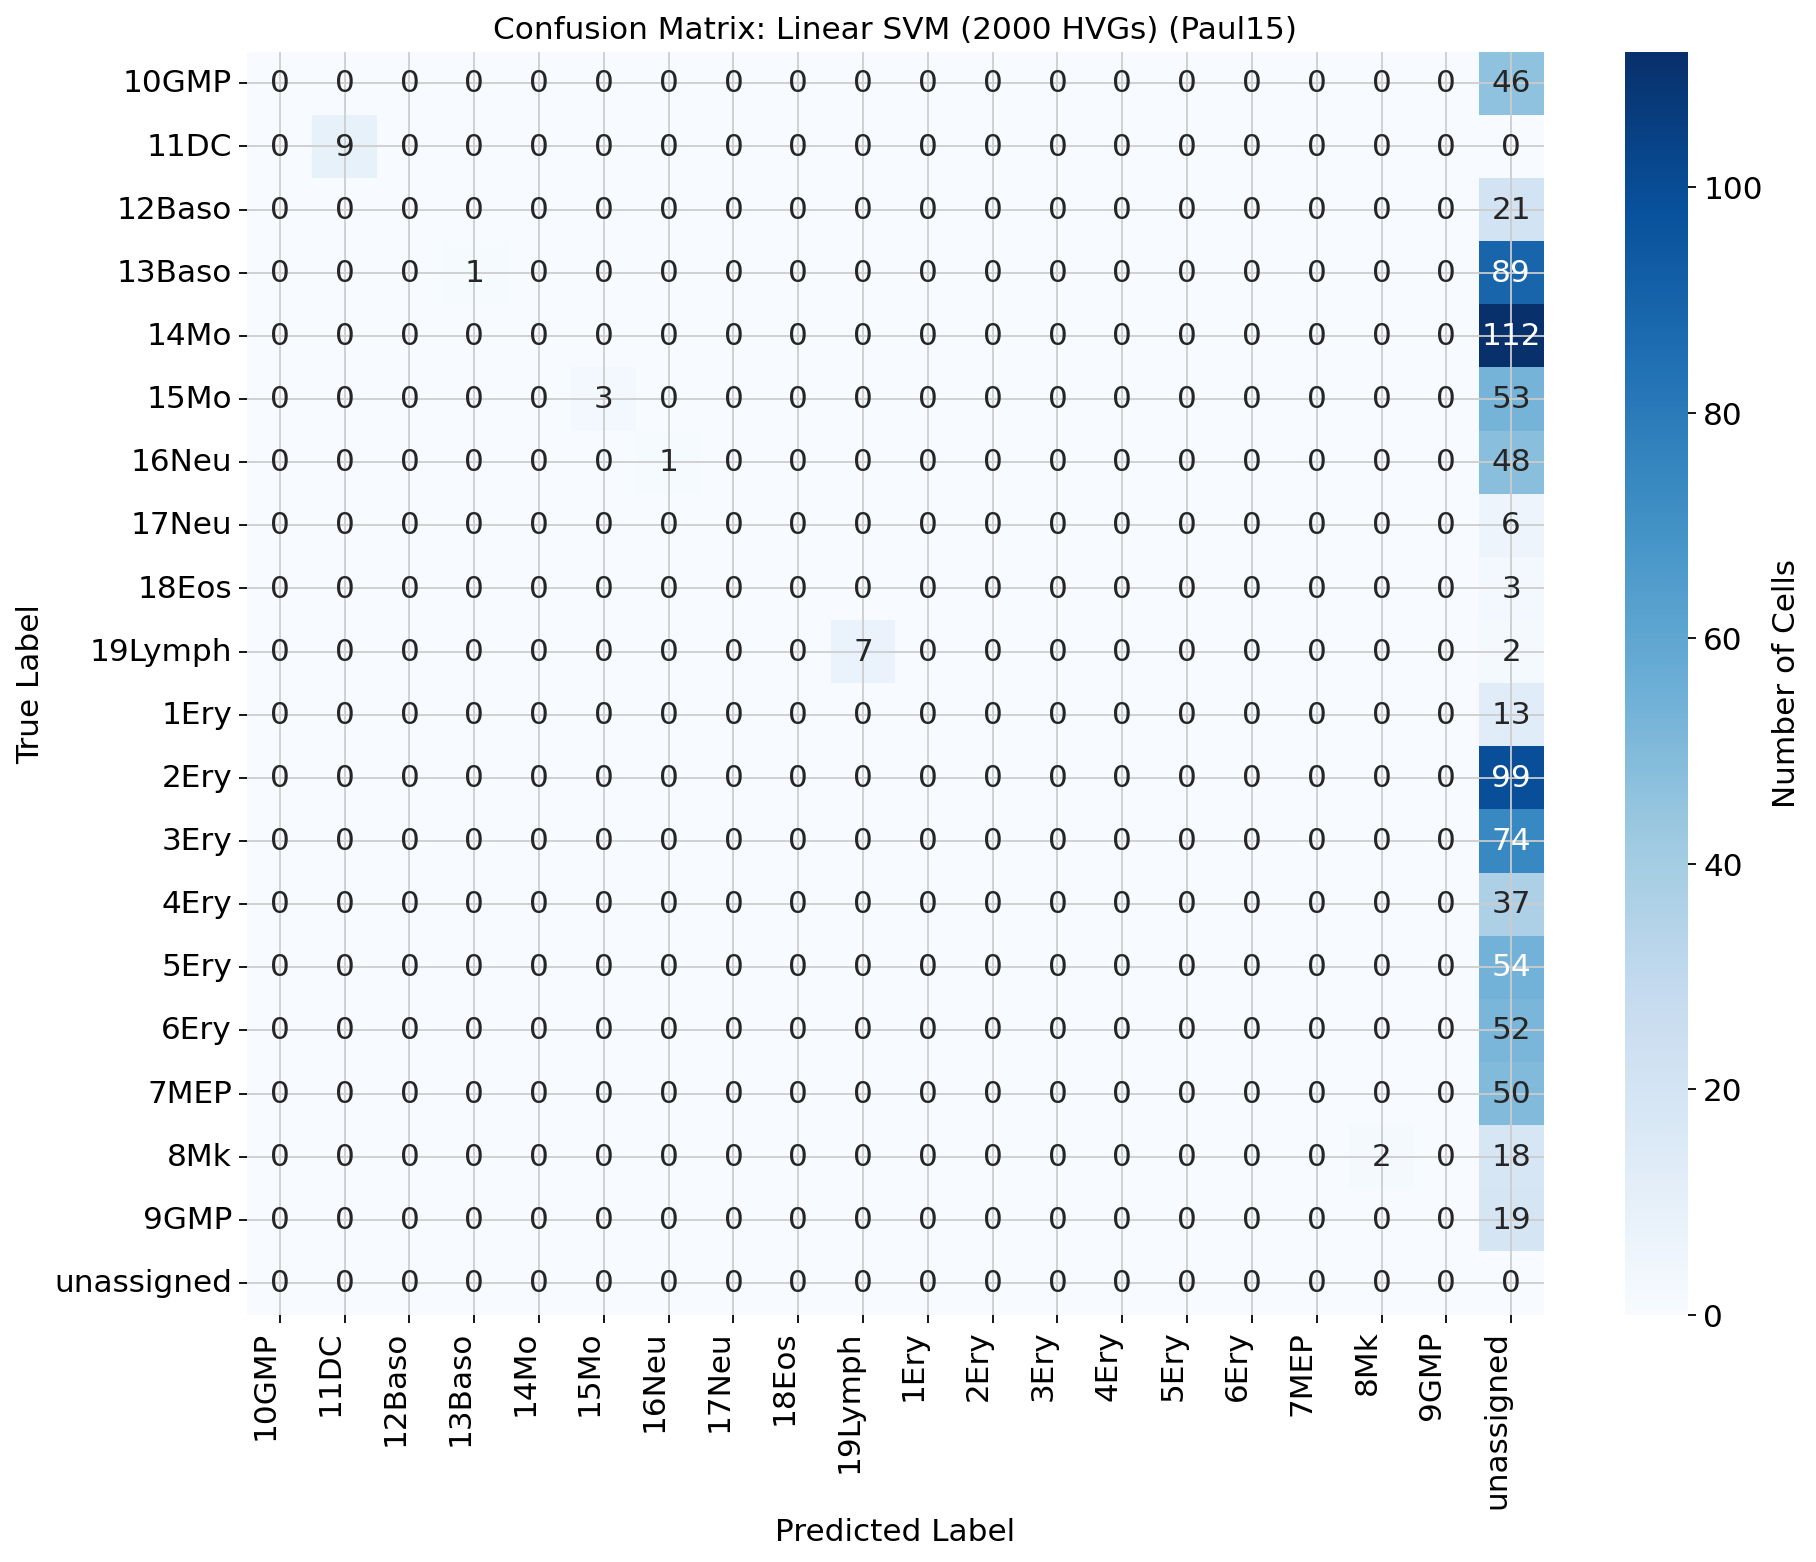


  RUNNING EXPERIMENT: RBF SVM (2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to 2000 reference genes

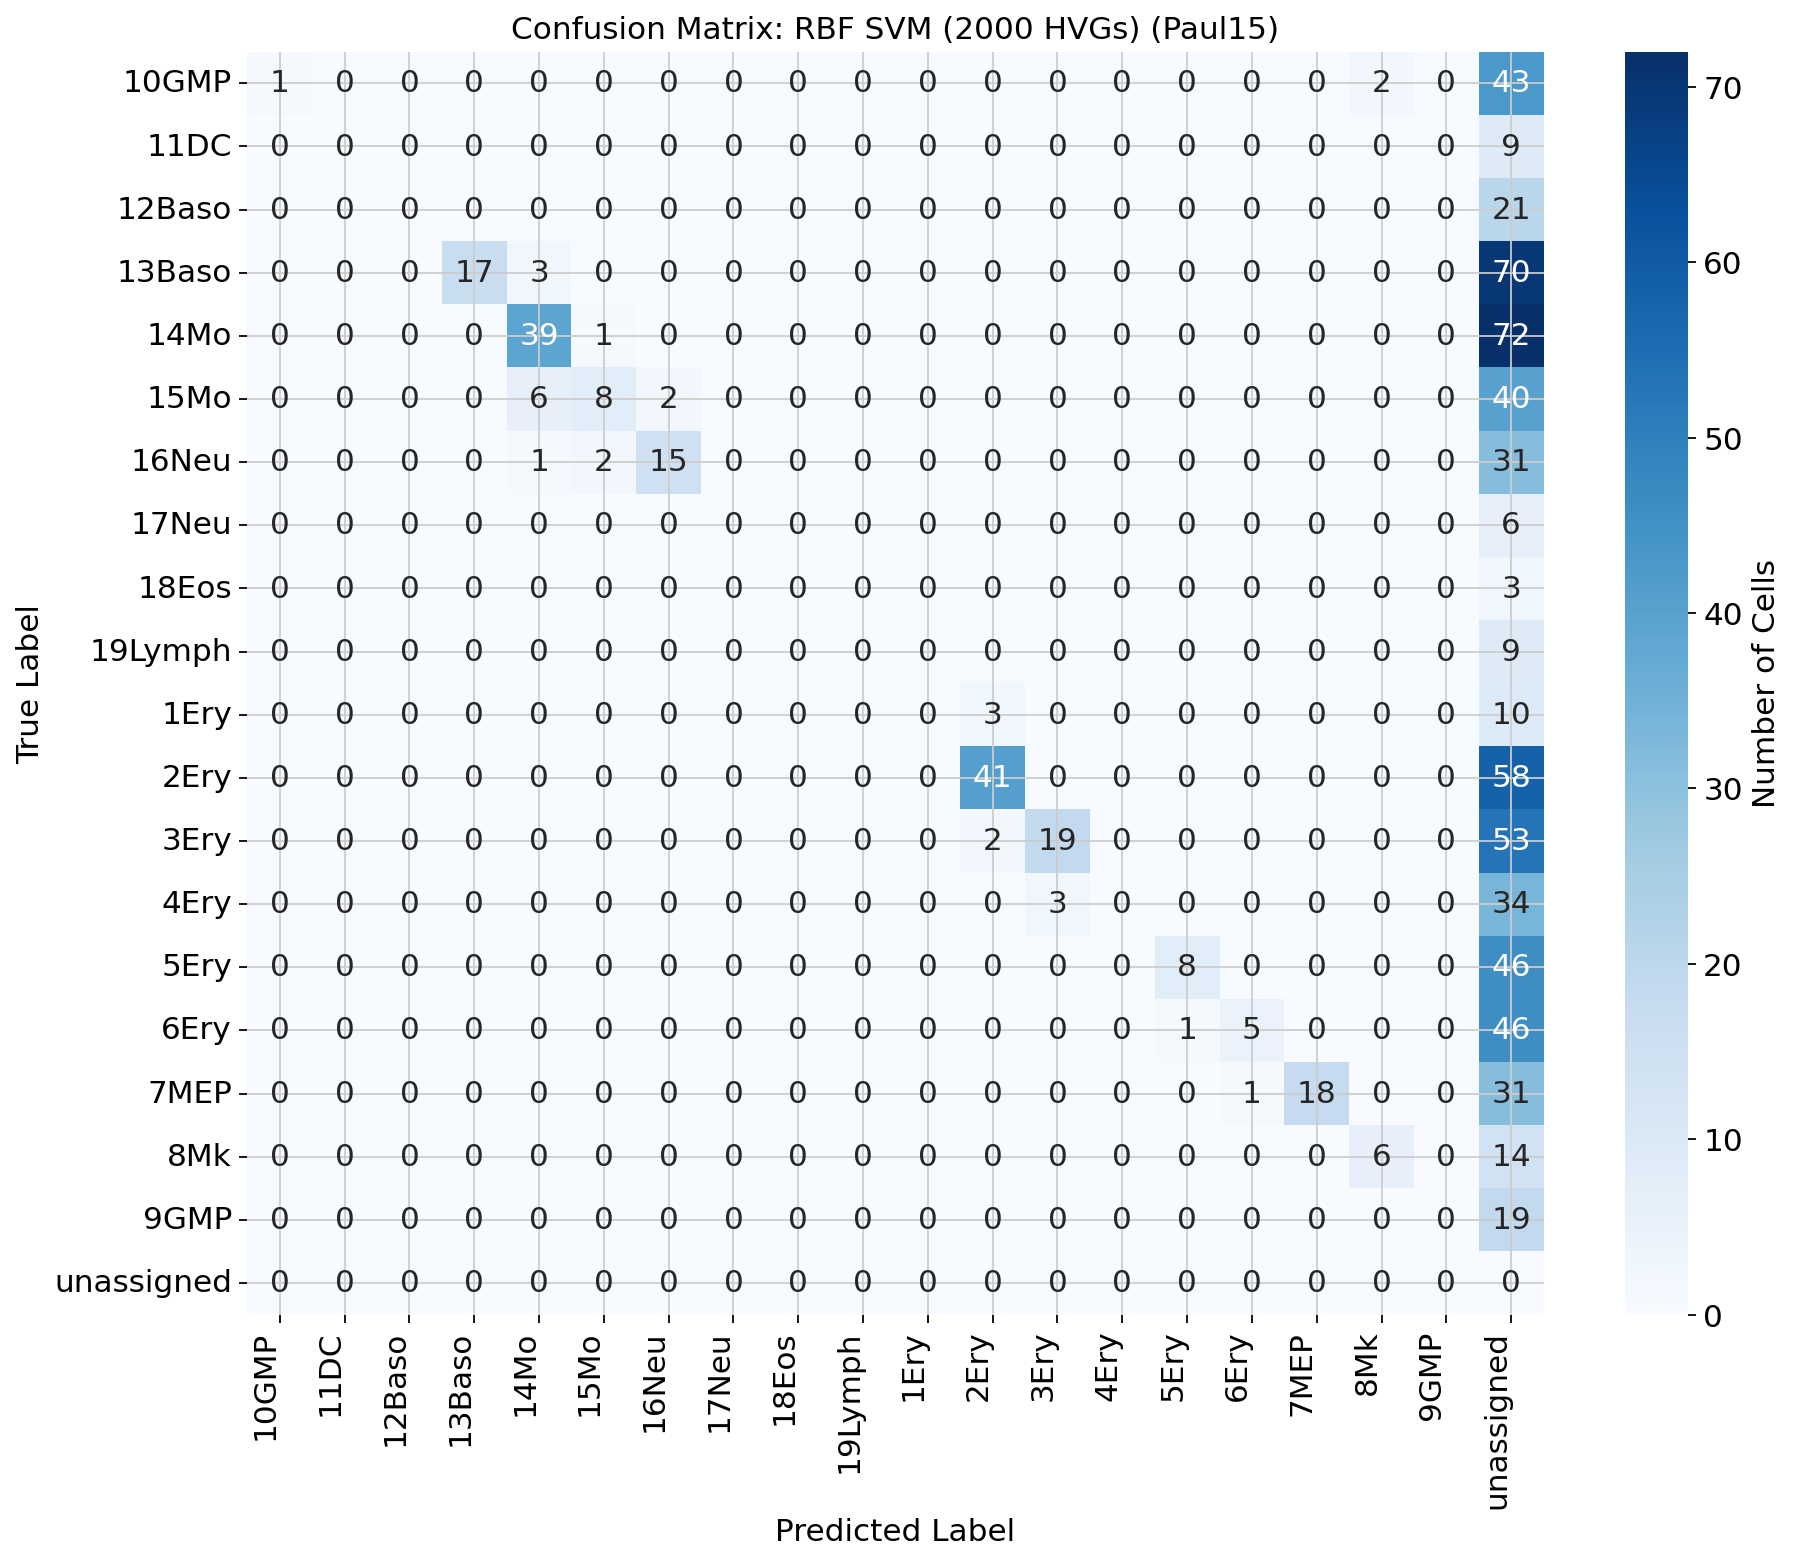


  RUNNING EXPERIMENT: RBF SVM (Balanced, 2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to 2000 r

/home/eva/Class-Project/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2776: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


              precision    recall  f1-score   support

       10GMP       1.00      0.02      0.04        46
        11DC       1.00      1.00      1.00         9
      12Baso       1.00      0.10      0.17        21
      13Baso       1.00      0.06      0.11        90
        14Mo       1.00      0.10      0.18       112
        15Mo       0.71      0.09      0.16        56
       16Neu       1.00      0.12      0.22        49
       17Neu       1.00      0.17      0.29         6
       18Eos       1.00      1.00      1.00         3
     19Lymph       1.00      1.00      1.00         9
        1Ery       0.00      0.00      0.00        13
        2Ery       0.90      0.36      0.52        99
        3Ery       1.00      0.15      0.26        74
        4Ery       0.00      0.00      0.00        37
        5Ery       0.75      0.06      0.10        54
        6Ery       1.00      0.04      0.07        52
        7MEP       1.00      0.22      0.36        50
         8Mk       0.88    

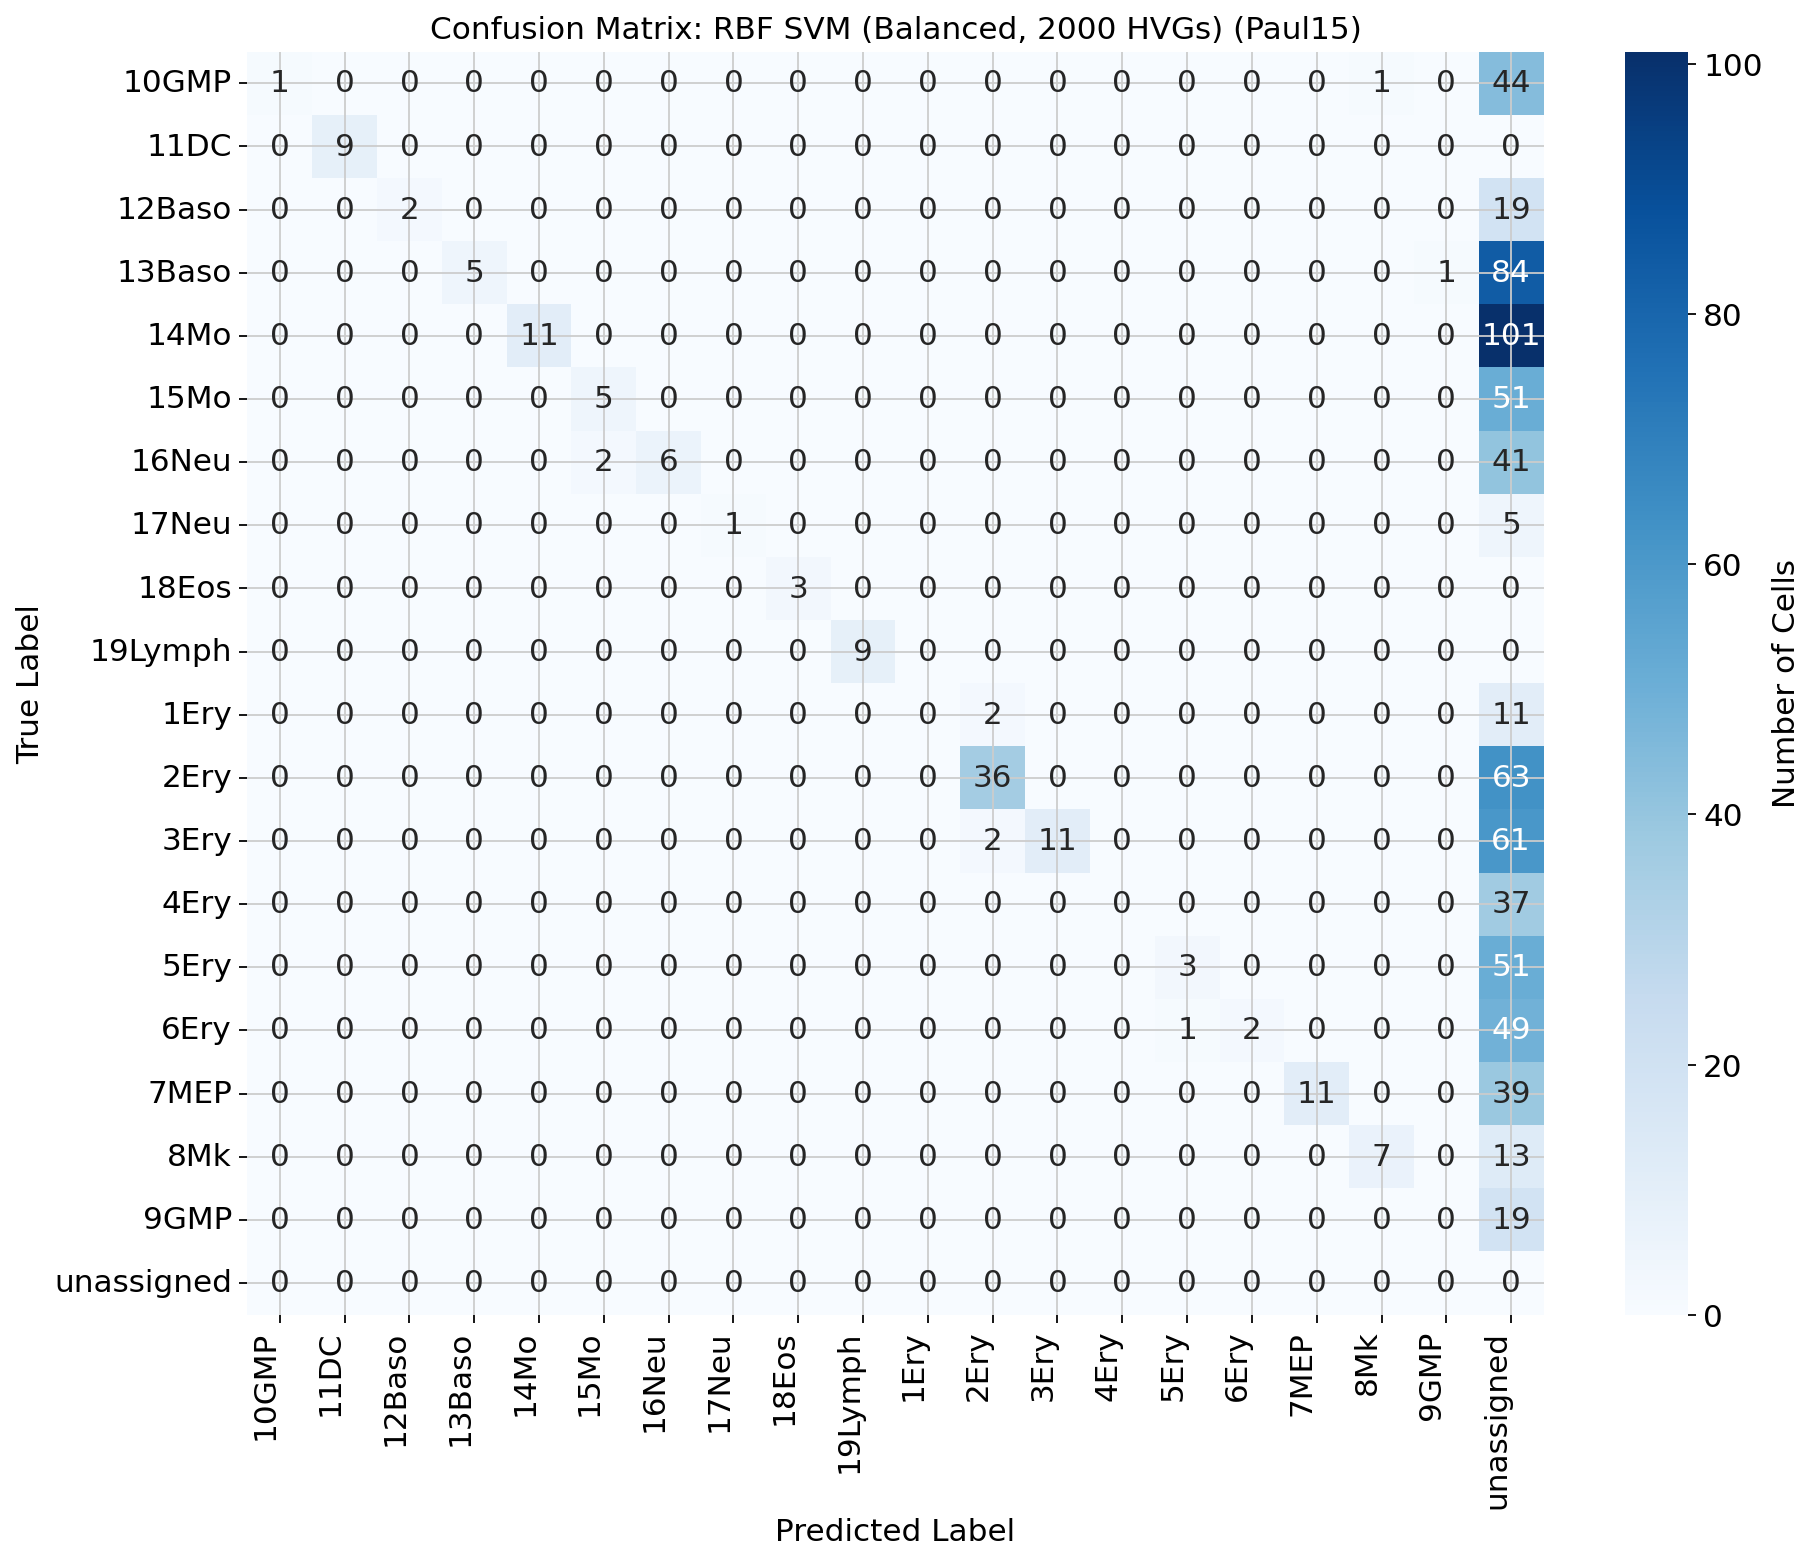


  RUNNING EXPERIMENT: RBF SVM (Balanced, C=10, 2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to

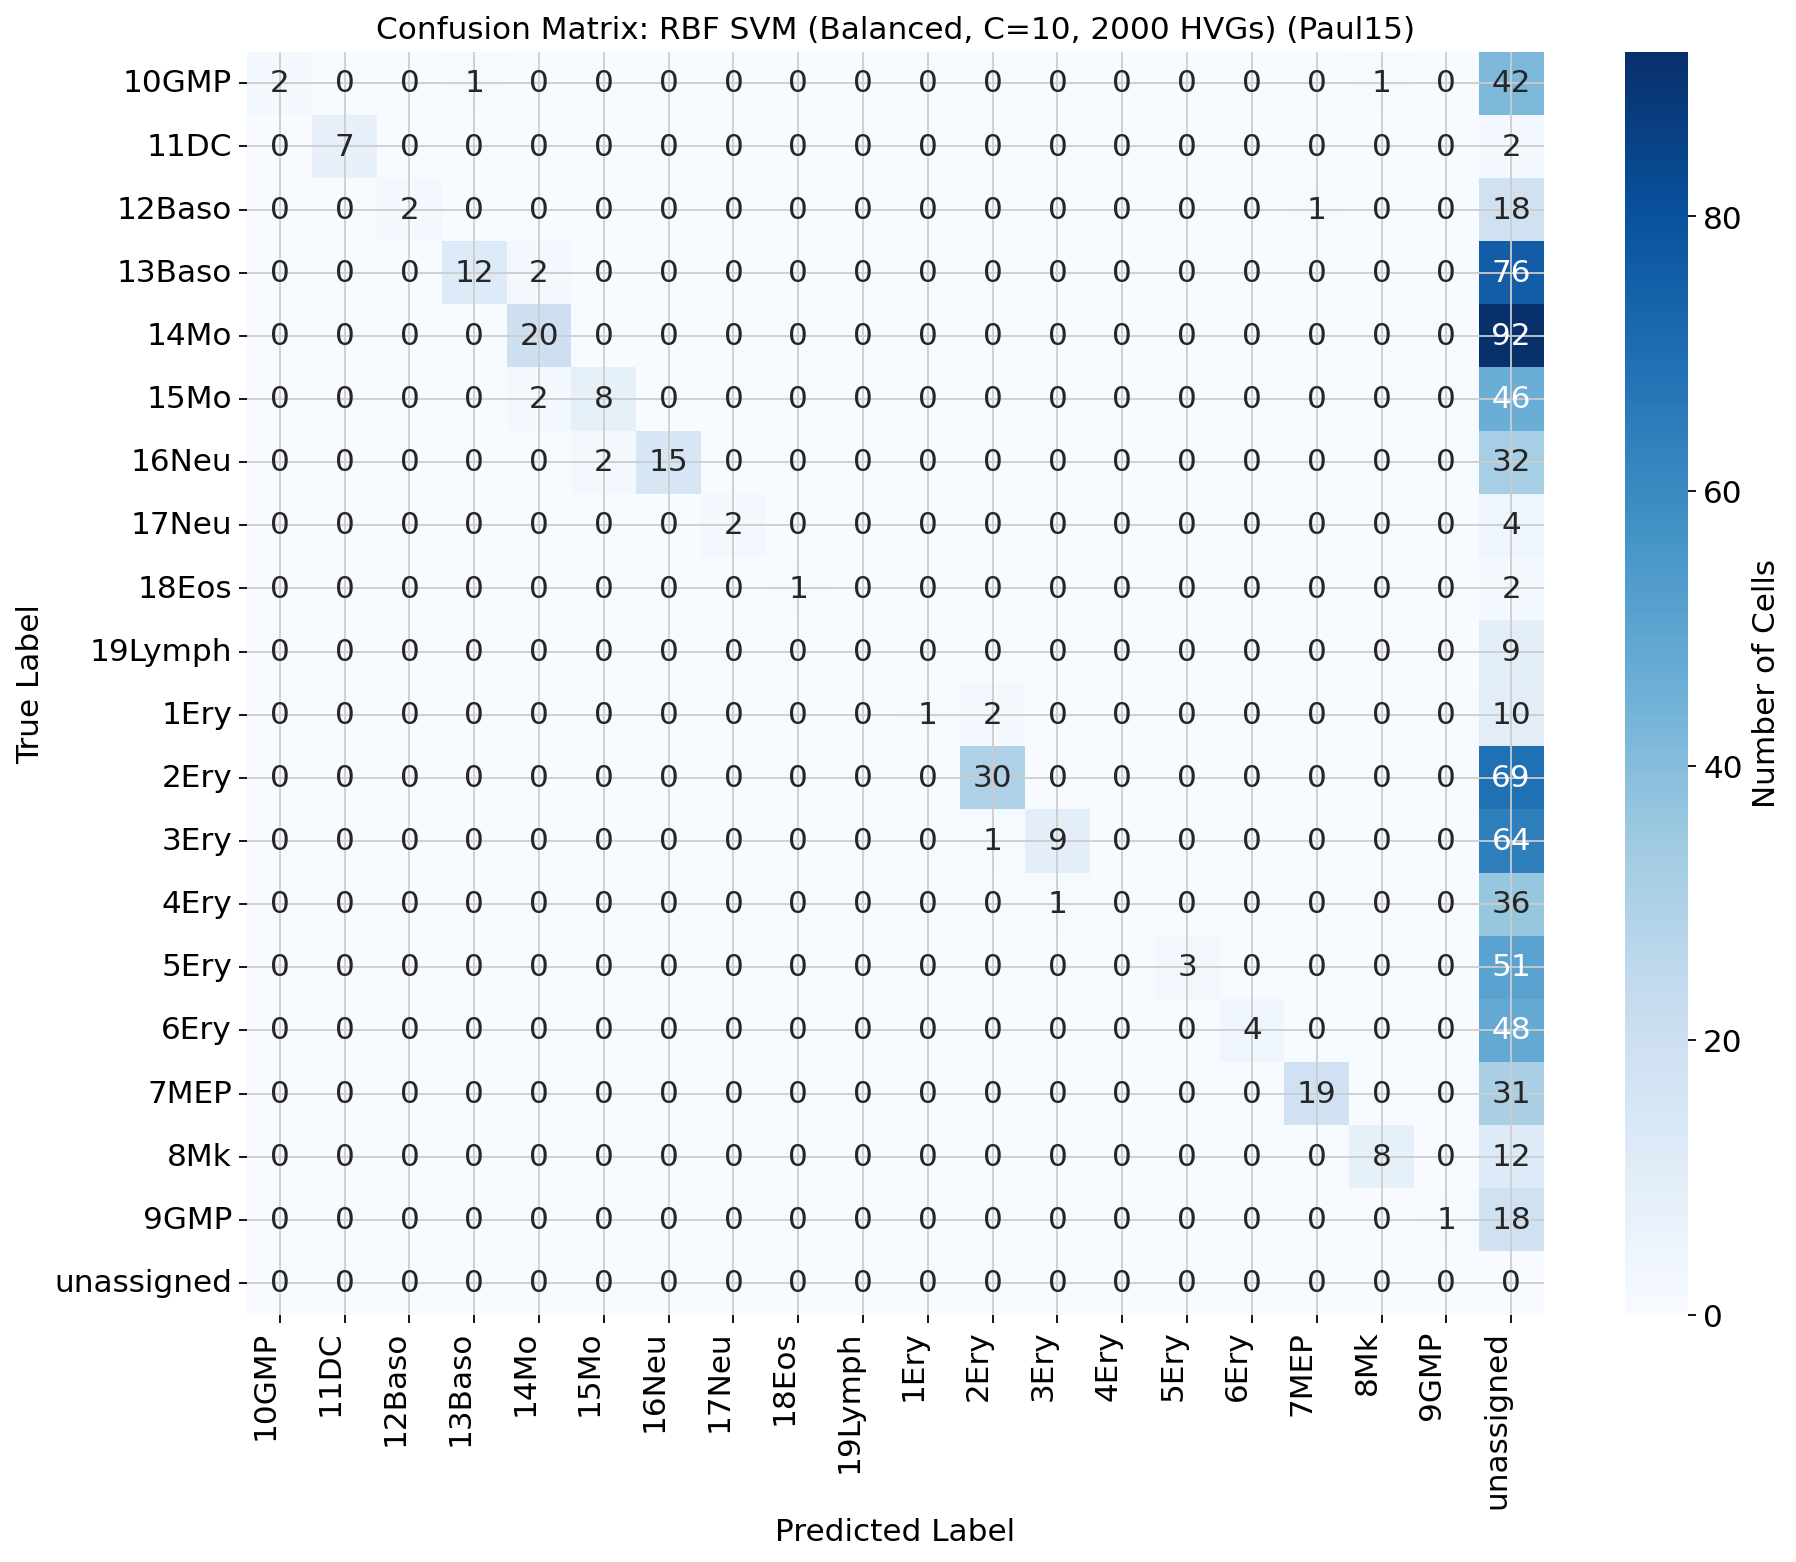



  FINAL RESULTS SUMMARY (paul15)
| Experiment                          |   Overall Accuracy |   Balanced Accuracy |      MCC |
|:------------------------------------|-------------------:|--------------------:|---------:|
| Linear SVM (2000 HVGs)              |           0.028083 |            1        | 1        |
| RBF SVM (2000 HVGs)                 |           0.216117 |            0.705933 | 0.849021 |
| RBF SVM (Balanced, 2000 HVGs)       |           0.148962 |            0.858597 | 0.922451 |
| RBF SVM (Balanced, C=10, 2000 HVGs) |           0.175824 |            0.829972 | 0.908087 |

--- Analysis Complete ---


In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score, # Import accuracy_score for overall accuracy
    balanced_accuracy_score, # For balanced accuracy
    matthews_corrcoef # For MCC
)
from sklearn.preprocessing import LabelBinarizer

# Adjust the path to import your package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Importing the main ScPredModel class and utilities
from scpred_py_final import ScPredModel # Adjusted to scpred_py_final as per your package name
from scpred_py_final import _analysis_utils # Assuming _analysis_utils is part of the package


print("--- Setting up environment for reproducibility ---")
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE) # For Python's built-in random module
# Set Scanpy's random state for operations that support it
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(8, 8)) # Set initial figure params

# Define paths for saving (though not directly used in this comparative analysis, good practice)
MODELS_DIR = '../models'
PREPROCESSED_DATA_DIR = '../data/preprocessed'
RAW_DATA_DIR = '../data/raw' # For Paul15 raw data

# Create directories if they don't exist (good practice for consistency)
print(f"Ensuring directories exist: {MODELS_DIR}, {PREPROCESSED_DATA_DIR}, and {RAW_DATA_DIR}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(RAW_DATA_DIR, exist_ok=True) # Ensure raw data directory exists
print("Directories ensured.")


# --- 1. Data Loading and Annotation (Paul15) ---
print("\n--- Step 1: Loading and Annotating Paul15 Data ---")

# Load Paul15 dataset
# Assuming 'paul15_data.h5ad' is in the '../data/raw/' directory.
# If you have your Paul15 data in a different format or location, adjust this line.
try:
    adata = sc.read_h5ad(os.path.join(RAW_DATA_DIR, 'paul15_data.h5ad'))
    print(f"Loaded Paul15 data from: {os.path.join(RAW_DATA_DIR, 'paul15_data.h5ad')}")
except FileNotFoundError:
    print(f"Warning: 'paul15_data.h5ad' not found in {RAW_DATA_DIR}. Attempting to load from Scanpy datasets if available.")
    # Fallback to a Scanpy dataset if a direct file isn't found.
    try:
        adata = sc.datasets.paul15()
        print("Loaded Paul15 data using sc.datasets.paul15().")
    except Exception as e:
        raise RuntimeError(f"Could not load Paul15 data. Please ensure 'paul15_data.h5ad' is in {RAW_DATA_DIR} or adjust the loading path. Error: {e}")

adata.var_names_make_unique()

# Ensure 'cell_type' column is present and categorical.
# Paul15 dataset often comes with 'paul15_clusters' or similar.
if 'paul15_clusters' in adata.obs.keys():
    adata.obs['cell_type'] = adata.obs['paul15_clusters'].astype('category')
    print("Assigned 'paul15_clusters' to 'cell_type' column.")
elif 'cell_type' in adata.obs.keys():
    adata.obs['cell_type'] = adata.obs['cell_type'].astype('category')
    print("Using existing 'cell_type' column.")
else:
    # If no 'paul15_clusters' or 'cell_type' exists, generate temporary labels via Louvain
    print("Warning: 'paul15_clusters' or 'cell_type' not found. Generating temporary labels via Louvain clustering...")
    temp_adata_for_labels = adata.copy()
    sc.pp.filter_cells(temp_adata_for_labels, min_genes=200)
    sc.pp.filter_genes(temp_adata_for_labels, min_cells=3)
    sc.pp.normalize_total(temp_adata_for_labels, target_sum=1e4)
    sc.pp.log1p(temp_adata_for_labels)
    sc.pp.highly_variable_genes(temp_adata_for_labels, min_mean=0.0125, max_mean=3, min_disp=0.5, flavor='seurat')
    temp_adata_hvg_for_labels = temp_adata_for_labels[:, temp_adata_for_labels.var.highly_variable].copy()
    sc.pp.scale(temp_adata_hvg_for_labels, max_value=10)
    sc.tl.pca(temp_adata_hvg_for_labels, svd_solver='arpack', random_state=RANDOM_STATE)
    sc.pp.neighbors(temp_adata_hvg_for_labels, n_neighbors=10, n_pcs=40, random_state=RANDOM_STATE)
    sc.tl.louvain(temp_adata_hvg_for_labels, random_state=RANDOM_STATE, key_added='cell_type')
    adata.obs['cell_type'] = temp_adata_hvg_for_labels.obs['cell_type'].reindex(adata.obs_names).astype('category')
    print("Generated temporary cell type labels.")

print(f"Full dataset (raw counts + Paul15 clusters) shape: {adata.shape}")
print(f"Full dataset .obs keys after labeling: {adata.obs.keys().tolist()}")
print("Cell type distribution (all data):\n", adata.obs['cell_type'].value_counts())
print("Data loading and labeling complete.")


# --- 2. Train-Test Split ---
print("\n--- Step 2: Splitting Data ---")
indices = range(adata.n_obs)
ref_idx, query_idx = train_test_split(
    indices, test_size=0.3, random_state=RANDOM_STATE, stratify=adata.obs['cell_type']
)
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()
print("Data splitting complete.")


# Calculate and report class imbalance
print("\n--- Class Imbalance Analysis ---")
print("Reference data class imbalance (proportion):\n", ref_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())
print("Query data class imbalance (proportion):\n", query_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())


# --- 3. Define the Experiment Runner Function ---
def run_scpred_experiment(experiment_name, ref_data, query_data, hvg_n_top_genes, svm_params, prediction_threshold=0.8):
    """
    A helper function to run a single scPred experiment with given parameters.
    Includes prediction threshold and passes probabilities for ROC AUC.
    """
    print("\n" + "="*50)
    print(f"  RUNNING EXPERIMENT: {experiment_name}")
    print("="*50)
    
    # --- Train Model ---
    model = ScPredModel()
    model.train(
        ref_adata=ref_data,
        cell_type_key='cell_type',
        n_components=30,
        hvg_n_top_genes=hvg_n_top_genes, # Pass HVGs as parameter
        hvg_flavor='seurat',  # Use 'seurat' flavor consistently
        **svm_params          # Pass all SVM parameters including class_weight
    )
    
    # --- Predict ---
    query_pred = model.predict(query_data, threshold=prediction_threshold)
    
    # --- Evaluate ---
    true_labels = query_pred.obs['cell_type']
    predicted_labels = query_pred.obs['scpred_prediction']
    
    # Calculate overall accuracy (including 'unassigned' as a potential prediction)
    overall_accuracy_score = accuracy_score(true_labels, predicted_labels)
    print(f"Overall Accuracy (including 'unassigned'): {overall_accuracy_score:.4f}")

    # Extract prediction probabilities for ROC AUC
    # Ensure these columns exist before trying to copy
    prob_cols = [col for col in query_pred.obs.columns if col.startswith('scpred_prob_')]
    y_pred_probs_df = None
    if prob_cols: # Check if the list is not empty
        y_pred_probs_df = query_pred.obs[prob_cols].copy()

    print(f"\n--- Results for: {experiment_name} ---")
    
    # Use the analysis util for the full report, passing y_pred_probs for ROC AUC
    metrics = _analysis_utils.evaluate_and_report_metrics(
        true_labels=true_labels,
        predicted_labels=predicted_labels,
        classifier_classes=model.classifier_.classes_, # Pass classifier classes
        y_pred_probs=y_pred_probs_df # Pass probabilities
    )
    
    # --- Visualize Confusion Matrix ---
    # Ensure labels are string type consistently, including "unassigned" if present
    true_labels_str = true_labels.astype(str)
    predicted_labels_str = predicted_labels.astype(str)

    # Ensure all unique labels (true and predicted, including 'unassigned') are used for CM labels
    cm_labels_str = sorted(list(set(true_labels_str.unique()) | set(predicted_labels_str.unique())))
    cm = confusion_matrix(true_labels_str, predicted_labels_str, labels=cm_labels_str)
    cm_df = pd.DataFrame(cm, index=cm_labels_str, columns=cm_labels_str)
    
    plt.figure(figsize=(12, 10)) # Increased size for more classes
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Cells'})
    plt.title(f'Confusion Matrix: {experiment_name} (Paul15)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=90, ha='right') # Rotate x-axis labels for Paul15
    plt.yticks(rotation=0) # Keep y-axis labels horizontal
    plt.tight_layout()
    plt.show()
    
    return {
        "Experiment": experiment_name,
        "Overall Accuracy": overall_accuracy_score, # Now correctly included
        "Balanced Accuracy": metrics.get('balanced_accuracy', np.nan),
        "MCC": metrics.get('mcc', np.nan),
        "ROC AUC Scores": metrics.get('roc_auc_scores', {}) # Include ROC AUC scores
    }


# --- 4. Run Comparative Experiments ---
print("\n\n--- Step 4: Running Comparative Analyses on paul15 ---")

# For Paul15, let's try more HVGs and a higher C value for the RBF kernel
# to see if it can handle the increased complexity.
experiments_to_run_paul15 = {
    "Linear SVM (2000 HVGs)": {
        'svm_kernel': 'linear', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': None
    },
    "RBF SVM (2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': None
    },
    "RBF SVM (Balanced, 2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': 'balanced'
    },
    "RBF SVM (Balanced, C=10, 2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 10.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': 'balanced'
    }
}

results_list_paul15 = []
for name, params in experiments_to_run_paul15.items():
    # Pass 2000 HVGs for all paul15 experiments and a prediction threshold
    result = run_scpred_experiment(name, ref_adata_raw.copy(), query_adata_raw.copy(), 2000, params, prediction_threshold=0.8)
    results_list_paul15.append(result)


# --- 5. Summarize Results ---
print("\n\n" + "="*50)
print("  FINAL RESULTS SUMMARY (paul15)")
print("="*50)

results_df_paul15 = pd.DataFrame(results_list_paul15)
# Display ROC AUC scores separately or as a nested dict if desired
# For a clean markdown table, we'll just show the main metrics.
# You can inspect results_list_paul15 for the full ROC AUC dicts.
print(results_df_paul15[['Experiment', 'Overall Accuracy', 'Balanced Accuracy', 'MCC']].to_markdown(index=False))

print("\n--- Analysis Complete ---")


In [ ]:
# --- 0. Imports and Setup ---
import scanpy as sc
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# Adjust the path to import your package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scpred_py_final import ScPredModel
from scpred_py_final import _analysis_utils

# --- Environment Setup ---
print("--- Setting up environment for reproducibility ---")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sc.settings.set_figure_params(dpi=80, facecolor='white')

# --- 1. Data Loading and Annotation ---
print("\n--- Step 1: Loading and Annotating paul15 Data ---")
adata = sc.datasets.paul15()
adata.var_names_make_unique()
# Use the existing cluster annotations
adata.obs['cell_type'] = adata.obs['paul15_clusters'].astype('category')
print("Data loading and labeling complete.")

# --- 2. Train-Test Split ---
print("\n--- Step 2: Splitting Data ---")
indices = range(adata.n_obs)
ref_idx, query_idx = train_test_split(
    indices, test_size=0.3, random_state=RANDOM_STATE, stratify=adata.obs['cell_type']
)
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()
print("Data splitting complete.")

# --- 3. Define the Experiment Runner Function ---
# (This function is identical to the one in the pbmc3k notebook, so it is omitted here for brevity)
# (Just copy the full `run_scpred_experiment` function here)
def run_scpred_experiment(experiment_name, ref_data, query_data, hvg_genes, svm_params):
    """
    A helper function to run a single scPred experiment with given parameters.
    """
    print("\n" + "="*50)
    print(f"  RUNNING EXPERIMENT: {experiment_name}")
    print("="*50)
    
    model = ScPredModel()
    model.train(
        ref_adata=ref_data,
        cell_type_key='cell_type',
        n_components=30,
        hvg_n_top_genes=hvg_genes, # Pass as parameter
        **svm_params
    )
    
    query_pred = model.predict(query_data)
    
    true_labels = query_pred.obs['cell_type']
    predicted_labels = query_pred.obs['scpred_prediction']
    
    print(f"\n--- Results for: {experiment_name} ---")
    accuracy = accuracy_score(true_labels, predicted_labels)
    print(f"Overall Accuracy: {accuracy:.4f}")
    
    metrics = _analysis_utils.evaluate_and_report_metrics(
        true_labels=true_labels,
        predicted_labels=predicted_labels,
        classifier_classes=model.classifier_.classes_
    )
    
    cm_labels_str = sorted(list(set(true_labels.astype(str).unique()) | set(predicted_labels.astype(str).unique())))
    cm = confusion_matrix(true_labels.astype(str), predicted_labels.astype(str), labels=cm_labels_str)
    cm_df = pd.DataFrame(cm, index=cm_labels_str, columns=cm_labels_str)
    
    plt.figure(figsize=(12, 10)) # Larger figure for more classes
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {experiment_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    return {
        "Experiment": experiment_name,
        "Accuracy": accuracy,
        "Balanced Accuracy": metrics.get('balanced_accuracy'),
        "MCC": metrics.get('mcc')
    }


# --- 4. Run Comparative Experiments ---
print("\n\n--- Step 4: Running Comparative Analyses on paul15 ---")

# For Paul15, let's try more HVGs and a higher C value for the RBF kernel
# to see if it can handle the increased complexity.
experiments_to_run_paul15 = {
    "Linear SVM (2000 HVGs)": {
        'svm_kernel': 'linear', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': None
    },
    "RBF SVM (2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': None
    },
    "RBF SVM (Balanced, 2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': 'balanced'
    },
    "RBF SVM (Balanced, C=10, 2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 10.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': 'balanced'
    }
}


results_list_paul15 = []
for name, params in experiments_to_run_paul15.items():
    # Pass 2000 HVGs for all paul15 experiments
    result = run_scpred_experiment(name, ref_adata_raw.copy(), query_adata_raw.copy(), 2000, params)
    results_list_paul15.append(result)


# --- 5. Summarize Results ---
print("\n\n" + "="*50)
print("  FINAL RESULTS SUMMARY (paul15)")
print("="*50)

results_df_paul15 = pd.DataFrame(results_list_paul15)
print(results_df_paul15.to_markdown(index=False))

print("\n--- Analysis Complete ---")

scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility ---

--- Step 1: Loading and Annotating paul15 Data ---
Data loading and labeling complete.

--- Step 2: Splitting Data ---
Data splitting complete.


--- Step 4: Running Comparative Analyses on paul15 ---

  RUNNING EXPERIMENT: Linear SVM (2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=1.0, class_weight='None'...


scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility ---

--- Step 1: Loading and Annotating paul15 Data ---
Data loading and labeling complete.

--- Step 2: Splitting Data ---
Data splitting complete.


--- Step 4: Running Comparative Analyses on paul15 ---

  RUNNING EXPERIMENT: Linear SVM (2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=1.0, class_weight='None'...
Training finished.
--- ScP

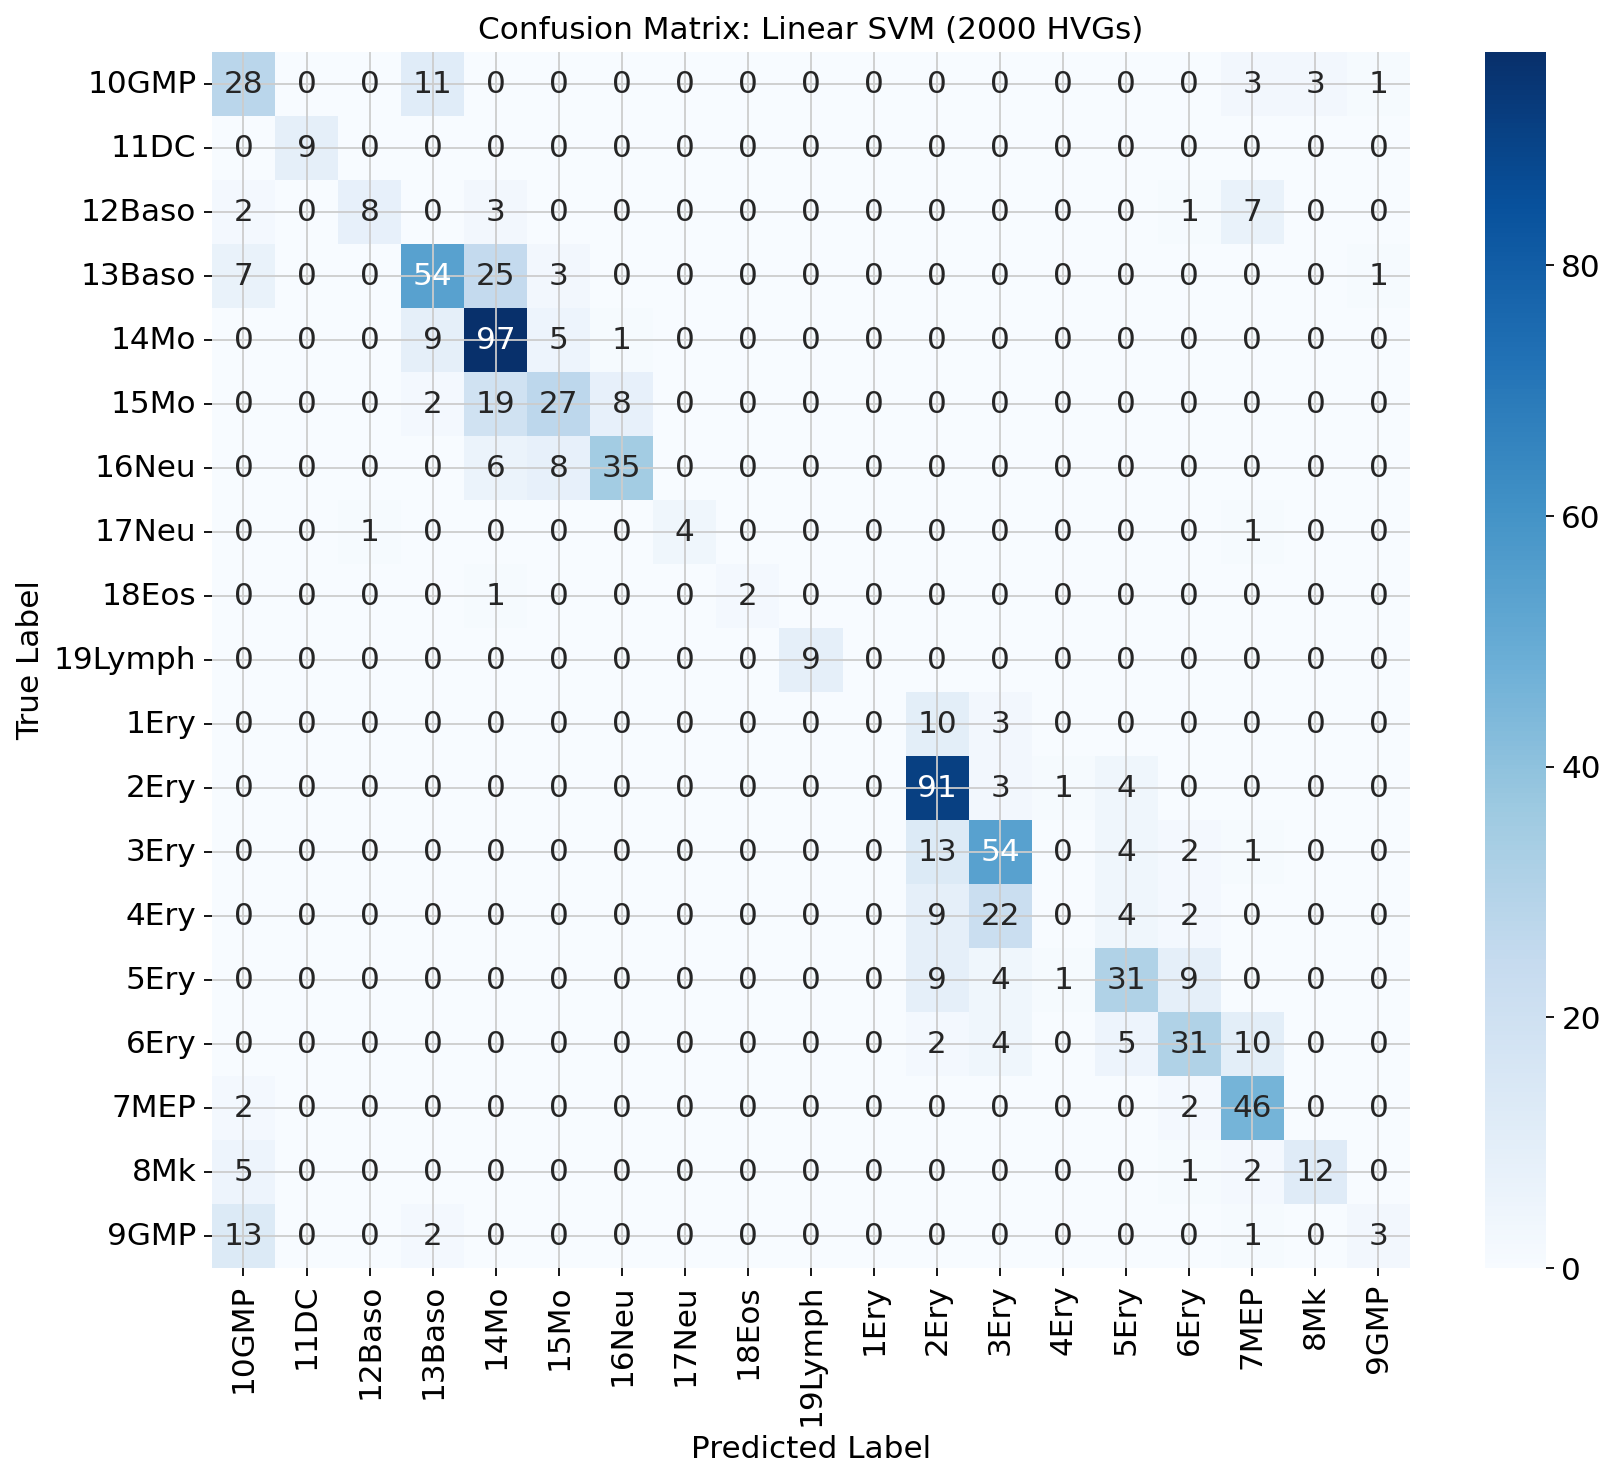


  RUNNING EXPERIMENT: RBF SVM (2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to 2000 reference genes

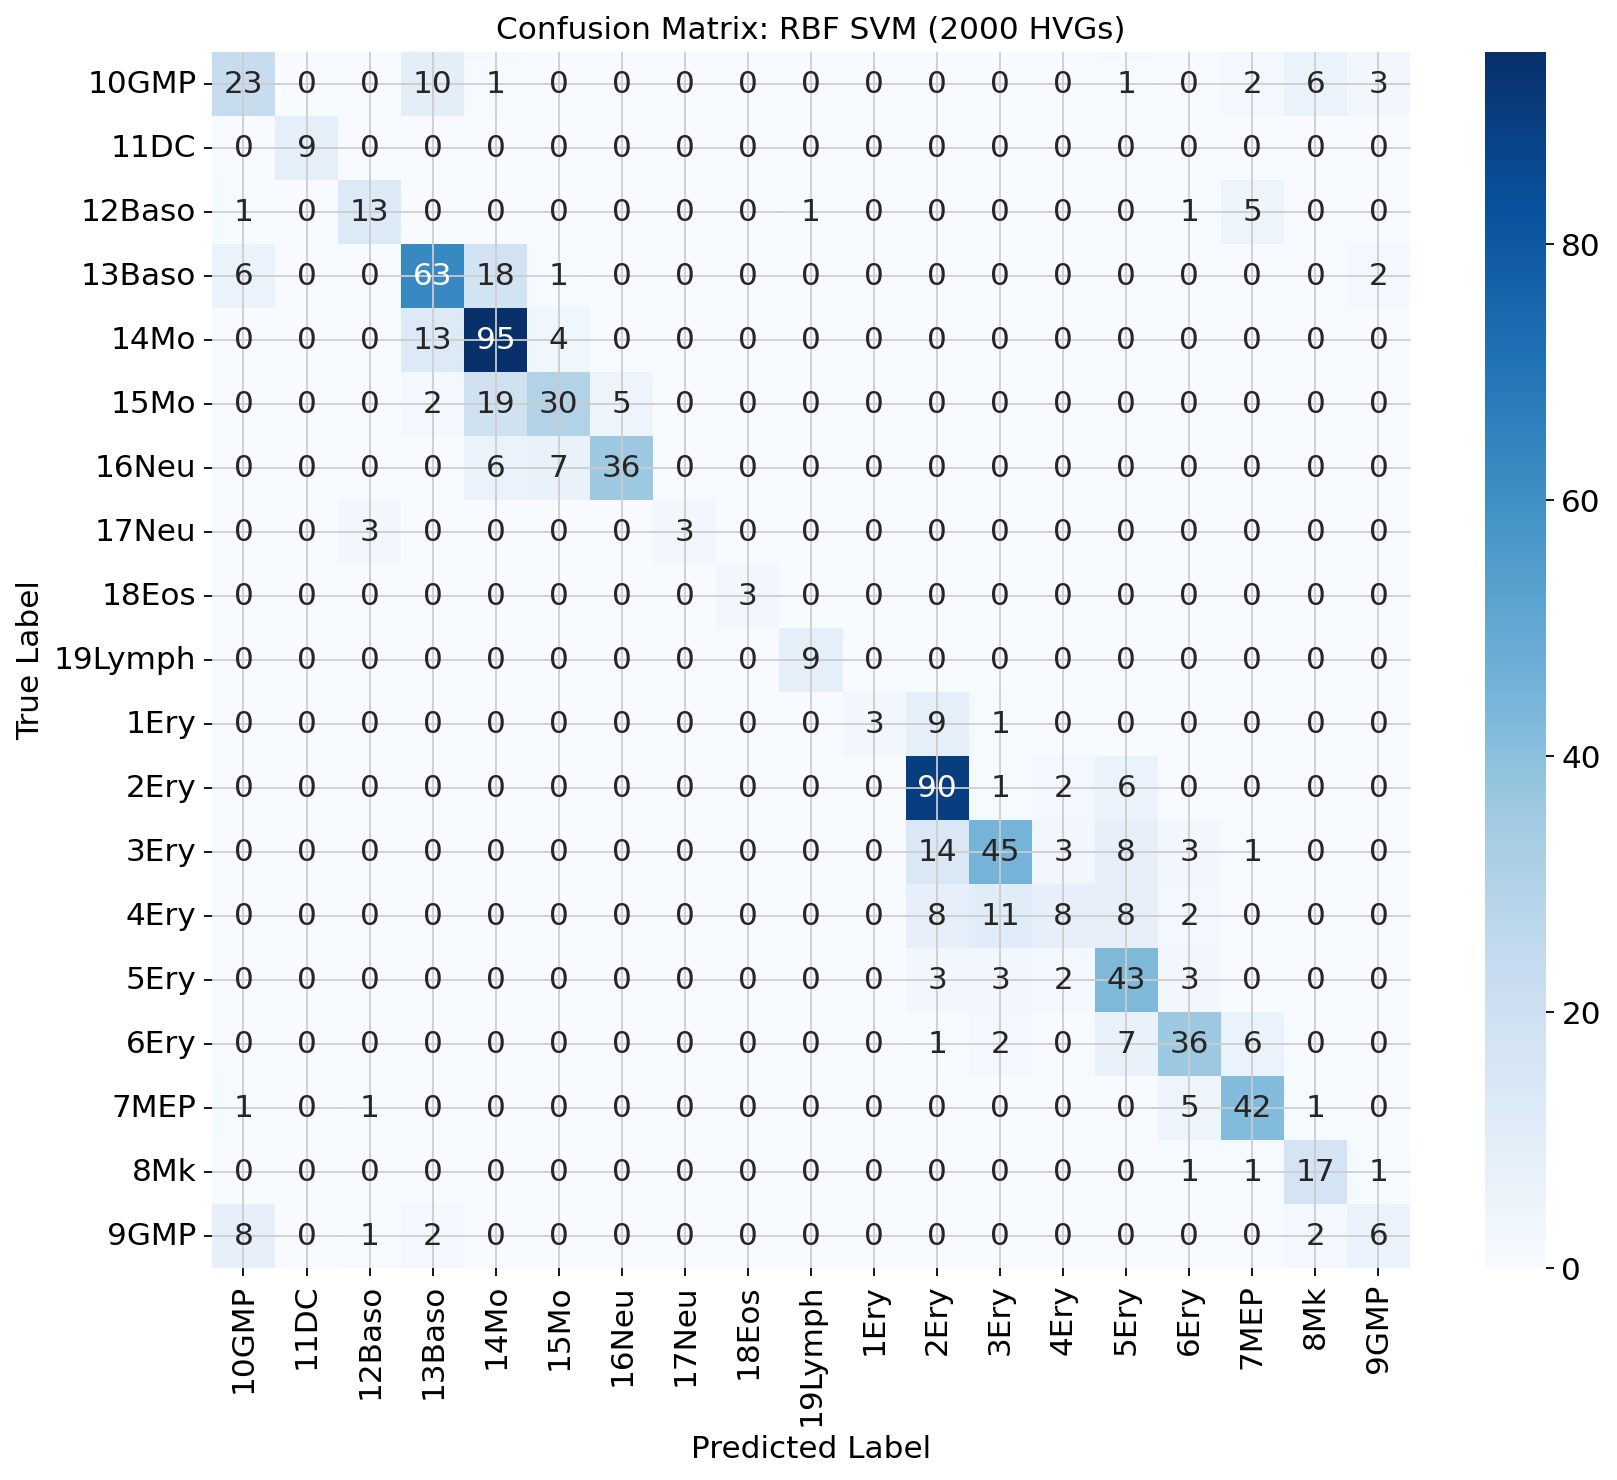


  RUNNING EXPERIMENT: RBF SVM (Balanced, 2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to 2000 r

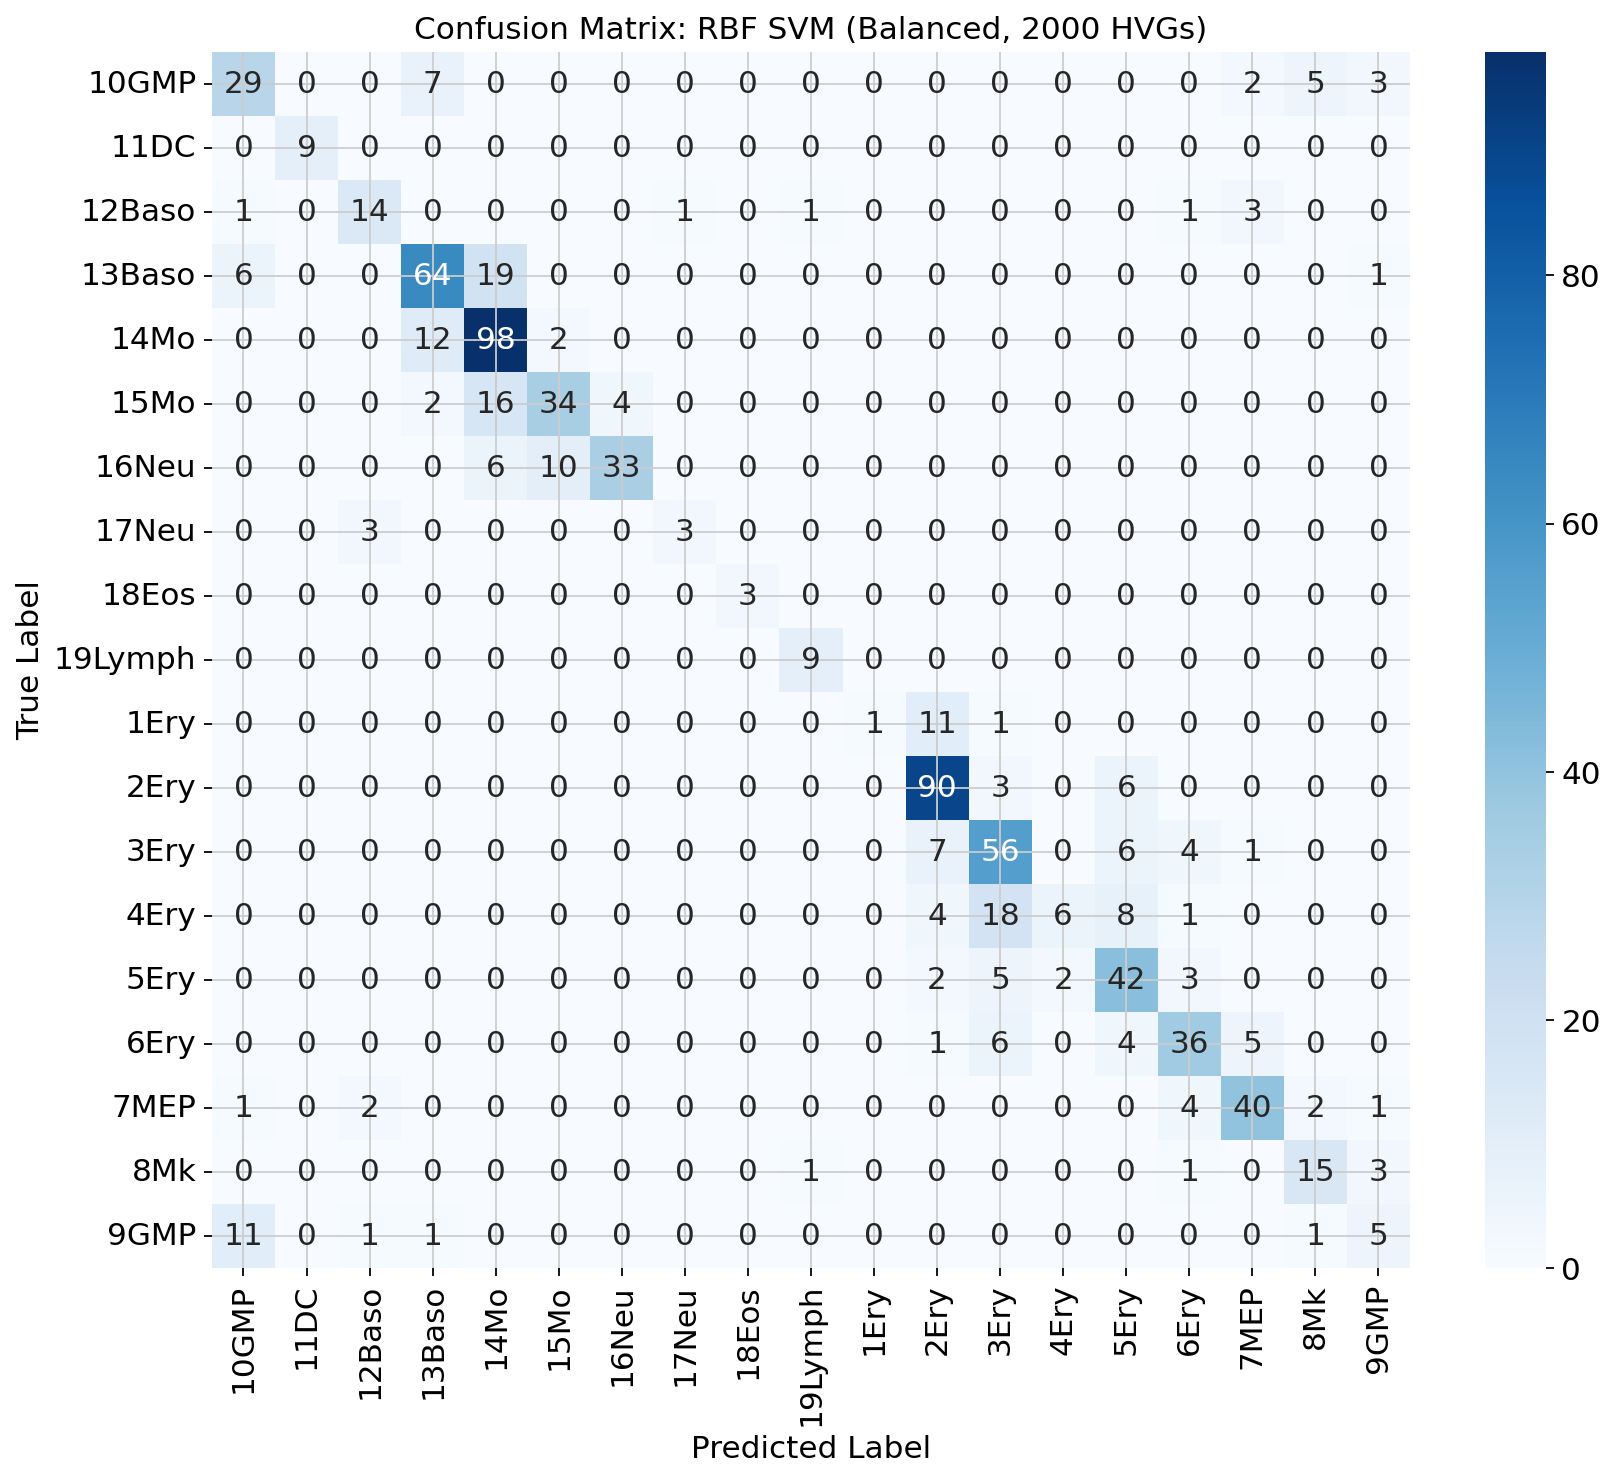


  RUNNING EXPERIMENT: RBF SVM (Balanced, C=10, 2000 HVGs)
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to

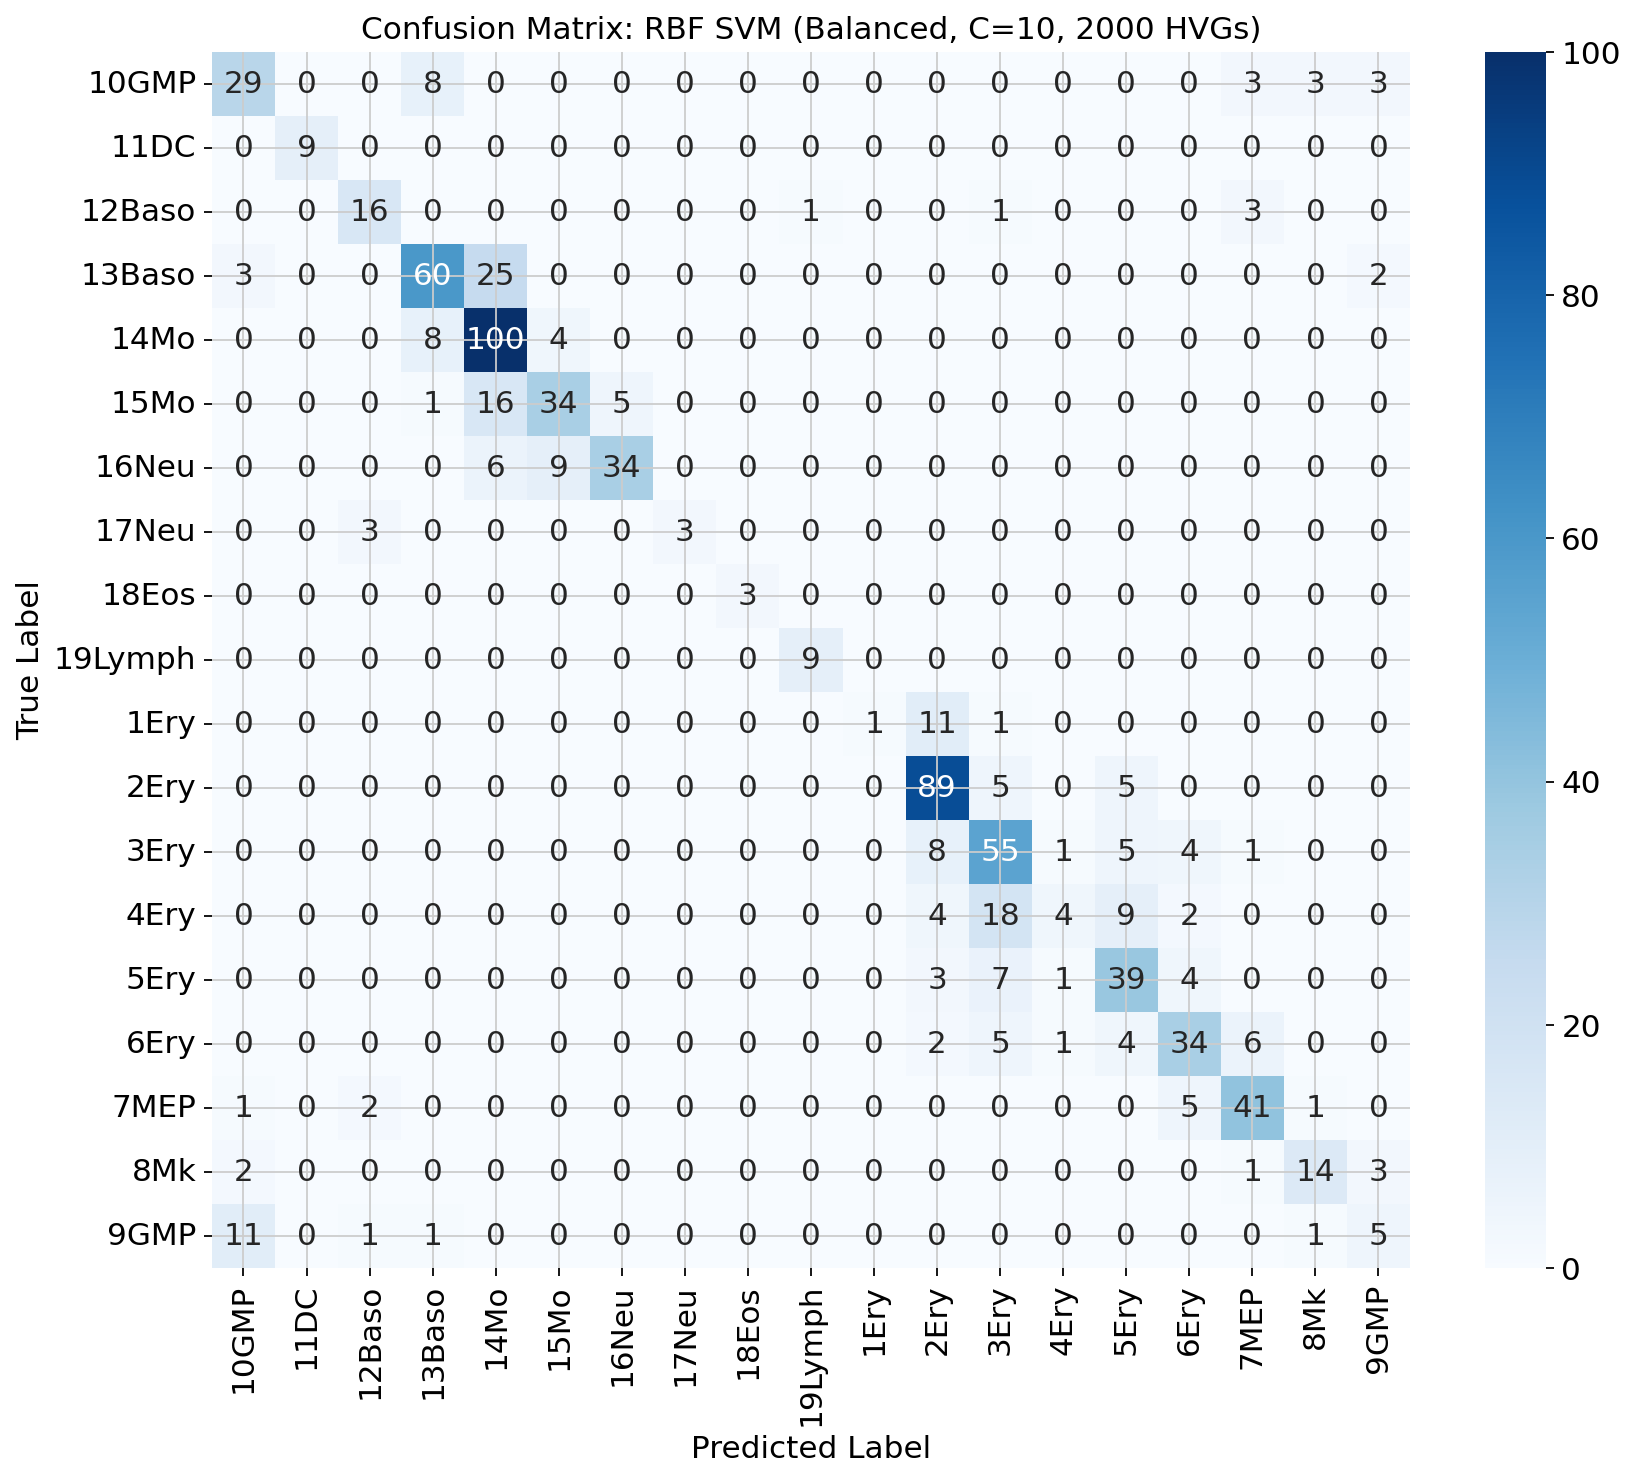



  FINAL RESULTS SUMMARY (paul15)
| Experiment                          |   Accuracy |   Balanced Accuracy |      MCC |
|:------------------------------------|-----------:|--------------------:|---------:|
| Linear SVM (2000 HVGs)              |   0.660562 |            0.604343 | 0.629907 |
| RBF SVM (2000 HVGs)                 |   0.700855 |            0.67875  | 0.674058 |
| RBF SVM (Balanced, 2000 HVGs)       |   0.716728 |            0.676421 | 0.691319 |
| RBF SVM (Balanced, C=10, 2000 HVGs) |   0.70696  |            0.670493 | 0.68075  |

--- Analysis Complete ---


In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# Adjust the path to import your package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scpred_py_final import ScPredModel
from scpred_py_final import _analysis_utils

# --- Environment Setup ---
print("--- Setting up environment for reproducibility ---")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sc.settings.set_figure_params(dpi=80, facecolor='white')

# --- 1. Data Loading and Annotation ---
print("\n--- Step 1: Loading and Annotating paul15 Data ---")
adata = sc.datasets.paul15()
adata.var_names_make_unique()
# Use the existing cluster annotations
adata.obs['cell_type'] = adata.obs['paul15_clusters'].astype('category')
print("Data loading and labeling complete.")

# --- 2. Train-Test Split ---
print("\n--- Step 2: Splitting Data ---")
indices = range(adata.n_obs)
ref_idx, query_idx = train_test_split(
    indices, test_size=0.3, random_state=RANDOM_STATE, stratify=adata.obs['cell_type']
)
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()
print("Data splitting complete.")

# --- 3. Define the Experiment Runner Function ---
# (This function is identical to the one in the pbmc3k notebook, so it is omitted here for brevity)
# (Just copy the full `run_scpred_experiment` function here)
def run_scpred_experiment(experiment_name, ref_data, query_data, hvg_genes, svm_params):
    """
    A helper function to run a single scPred experiment with given parameters.
    """
    print("\n" + "="*50)
    print(f"  RUNNING EXPERIMENT: {experiment_name}")
    print("="*50)
    
    model = ScPredModel()
    model.train(
        ref_adata=ref_data,
        cell_type_key='cell_type',
        n_components=30,
        hvg_n_top_genes=hvg_genes, # Pass as parameter
        **svm_params
    )
    
    query_pred = model.predict(query_data)
    
    true_labels = query_pred.obs['cell_type']
    predicted_labels = query_pred.obs['scpred_prediction']
    
    print(f"\n--- Results for: {experiment_name} ---")
    accuracy = accuracy_score(true_labels, predicted_labels)
    print(f"Overall Accuracy: {accuracy:.4f}")
    
    metrics = _analysis_utils.evaluate_and_report_metrics(
        true_labels=true_labels,
        predicted_labels=predicted_labels,
        classifier_classes=model.classifier_.classes_
    )
    
    cm_labels_str = sorted(list(set(true_labels.astype(str).unique()) | set(predicted_labels.astype(str).unique())))
    cm = confusion_matrix(true_labels.astype(str), predicted_labels.astype(str), labels=cm_labels_str)
    cm_df = pd.DataFrame(cm, index=cm_labels_str, columns=cm_labels_str)
    
    plt.figure(figsize=(12, 10)) # Larger figure for more classes
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {experiment_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    return {
        "Experiment": experiment_name,
        "Accuracy": accuracy,
        "Balanced Accuracy": metrics.get('balanced_accuracy'),
        "MCC": metrics.get('mcc')
    }


# --- 4. Run Comparative Experiments ---
print("\n\n--- Step 4: Running Comparative Analyses on paul15 ---")

# For Paul15, let's try more HVGs and a higher C value for the RBF kernel
# to see if it can handle the increased complexity.
experiments_to_run_paul15 = {
    "Linear SVM (2000 HVGs)": {
        'svm_kernel': 'linear', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': None
    },
    "RBF SVM (2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': None
    },
    "RBF SVM (Balanced, 2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 1.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': 'balanced'
    },
    "RBF SVM (Balanced, C=10, 2000 HVGs)": {
        'svm_kernel': 'rbf', 'svm_c': 10.0, 'svm_random_state': RANDOM_STATE, 'svm_class_weight': 'balanced'
    }
}


results_list_paul15 = []
for name, params in experiments_to_run_paul15.items():
    # Pass 2000 HVGs for all paul15 experiments
    result = run_scpred_experiment(name, ref_adata_raw.copy(), query_adata_raw.copy(), 2000, params)
    results_list_paul15.append(result)


# --- 5. Summarize Results ---
print("\n\n" + "="*50)
print("  FINAL RESULTS SUMMARY (paul15)")
print("="*50)

results_df_paul15 = pd.DataFrame(results_list_paul15)
print(results_df_paul15.to_markdown(index=False))

print("\n--- Analysis Complete ---")